## Preamble

In [1]:
%pip install pycountry-24.6.1-py3-none-any.whl -q
%pip install country_converter-1.3.1-py3-none-any.whl -q
#%pip install Unidecode-1.4.0-py3-none-any.whl -q

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import IPython

# restart python kernel
IPython.Application.instance().kernel.do_shutdown(restart=True)

{'status': 'ok', 'restart': True}

In [1]:
try:
    print(f"Spark version {sc.version}")
except:
    %run ../spark-instance.ipynb

SparkConf created
Started SparkSession
Spark version 3.5.3
You should be able to access the Spark UI at: https://dacs-compute-gate.ewi.utwente.nl:9999/user/g.luvizottocesar@utwente.nl/proxy/4040/stages/
Note that you may have to Enable extensions first via the Extension Manager.


In [2]:
#clean_spark()

In [3]:
from datetime import datetime, timedelta, date
from dateutil import rrule
import re
import itertools
import logging
import os
from glob import glob
import numpy as np
import json
import time

from collections import defaultdict
import publicsuffixlist as psl
import pandas as pd
import networkx as nx
from graphframes import GraphFrame
from functools import reduce
import pycountry
import country_converter
from pathlib import Path

import pyspark.sql.types as pst
import pyspark.sql.functions as psf
from pyspark.sql.window import Window

import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

In [4]:
sc.setCheckpointDir("checkpoint/")

In [5]:
# Create logger
logger = logging.getLogger("dmarc")
logger.setLevel(logging.INFO)

# Prevent duplicate logs if logger already has handlers
if not logger.handlers:
    # Create file handler
    file_handler = logging.FileHandler("logs.log", encoding='utf-8')
    file_handler.setLevel(logging.INFO)
    
    # Create formatter
    formatter = logging.Formatter(
        fmt='%(asctime)s %(levelname)-8s %(message)s',
        datefmt='%Y-%m-%d %H:%M:%S'
    )
    
    # Add formatter to handler
    file_handler.setFormatter(formatter)
    
    # Add handler to logger
    logger.addHandler(file_handler)
else:
    print("logger already exist!")

# Optionally, prevent propagation to root logger to avoid duplicates
logger.propagate = False

In [6]:
## Create PublicSuffixList
# Update PSL.dat if older than a day
if time.time() - os.path.getctime("/opt/conda/lib/python3.10/site-packages/publicsuffixlist/public_suffix_list.dat") > (24*3600):
    print("Updating PSL file.")
    !python -m publicsuffixlist.update
else:
    !python -m publicsuffixlist.test 

Updating PSL file.
This is a script to download the latest PSL file.
Do not run this repeatedly more than once per day.
PSL updated
last-modified: Wed, 29 Oct 2025 17:39:37 GMT


In [7]:
# Base prefix of fDNS warehouse data
FDNS_WAREHOUSE_BASE = "category=fdns/type=warehouse"
# Prefix format() template for (source, date)-partition fDNS warehouse data
FDNS_SOURCE_DT_PARTITION_FMT_TEMPLATE = os.path.join(FDNS_WAREHOUSE_BASE, "source={source}", "year={year}", "month={month:02d}", "day={day:02d}")

#sources = ["com", "net", "org", "czds", "alexa", "majestic", "opencc", "radar", "tranco", "umbrella", "crux"]

# additional sources:
# infra:mx, infra:ns
# alexa is old; not found in our recent data set

In [8]:
source = "ct_logs"
ct_logs_dates = [  # one snapshot a month is enough to give trends
    datetime(2024, 2, 15),
    datetime(2024, 3, 15),
    datetime(2024, 4, 15),
    datetime(2024, 5, 15),
    datetime(2024, 6, 15),
    datetime(2024, 7, 15),
    datetime(2024, 8, 15),
    datetime(2024, 9, 15),
    datetime(2024, 10, 15),
    datetime(2024, 11, 15),
    datetime(2024, 12, 15),
    datetime(2025, 1, 15),
    datetime(2025, 2, 15),
    datetime(2025, 3, 15),
    datetime(2025, 4, 15),
    datetime(2025, 5, 15),
    datetime(2025, 6, 15),
    datetime(2025, 7, 15),
    datetime(2025, 8, 15),
    datetime(2025, 9, 15),
    datetime(2025, 10, 9),
]
last_snapshot = ct_logs_dates[-1]
print(source, "last snapshot:", last_snapshot)

ct_logs last snapshot: 2025-10-09 00:00:00


In [9]:
# this is useful for manual inspection
if False:
    psl_obj = psl.PublicSuffixList()
    
    def show_gov_tlds():
        tsv_files = glob("country_tsv_files/*.tsv")
        tsv_files.sort()
        for tsv in tsv_files:
            print(tsv)
            pdf = pd.read_csv(tsv, sep='\t')
            filtered_pdf = pdf[~pdf["Website"].isna()].copy()
            filtered_pdf["apex_domain"] = filtered_pdf["Website"].apply(lambda x: str(x).replace("http://", "").replace("https://", "").split("/")[0])
            filtered_pdf["tld"] = filtered_pdf["apex_domain"].apply(lambda x: psl_obj.publicsuffix(str(x)))
            aggr_pdf = filtered_pdf.groupby(["tld"]).size().reset_index(name="count").sort_values(by='count', ascending=False)
            display(aggr_pdf)
    
    show_gov_tlds()

# old manual assignment...
#gov_tlds = [
#    "gv.at", "gov.bm", "gov.cm", "gov.cl", "gob.cl", "gob.cu", "gov.cu", "gov.tl", "gov.gh", "gov.in", "go.id",
#    "gov.ie", "gov.lv", "gov.my", "gov.ma", "gov.np", "govt.nz", "stat.no", "gob.pe", "gov.ph", "gov.pt",
#    "gov.ru", "gov.sg", "gov.za", "gov.ua", "gov.uk", "gub.uy" 
#]

In [10]:
# what are the top gov domain?
# if I have .gov.pl, .gov.cl and .gov.br, then .gov has 3
# gub.uy has 1 (uruguay only)

psl_obj = psl.PublicSuffixList()
tld_regex_dict = {}
for tld in psl.PublicSuffixList()._publicsuffix:
    # https://github.com/publicsuffix/list/wiki/Format
    tld_escaped = tld.replace("*.", "[a-zA-Z]*.?").replace("!", "")  # ! is a prefference over the generic rule
    _domain_pattern = fr'([^.]+)[.]({tld_escaped}).?$'
    tld_clean = tld.replace("*.", "").replace("!", "")
    tld_regex_dict[tld_clean] = re.compile(_domain_pattern, re.IGNORECASE)


def extract_apex_domain_logic(x: str, psl_obj, tld_regex_dict):
    # x: query_name
    if x is None:
        return None

    # invalid case:query:_dmarc.siter.io., txt_text contains ma""ilinblue.com!10m
    #                                                           x
    # invalid case:query:_dmarc.fnspfdr.sk, txt_text contains rua=mailto:dmarc@hostcreators.sk ruf=mailto:dmarc@hostcreators.sk; resulting in a rua_domain:hostcreators.sk hostcreators.sk
    #                                                                                         x
    if '"' in x or ' ' in x:
        return None

    tld = psl_obj.publicsuffix(x)  # get the com.br from a.example.com.br
    if tld is None:
        return None  # invalid suffix

    # to avoid cases such as v.ua
    tld_escaped = tld.replace("*.", "")
    if tld_escaped == x.rstrip("."):
        return tld_escaped

    x_escaped = x
    # rfc7489#section-6.2
    #   For example, the URI "mailto:reports@example.com!50m" would request
    #   that a report be sent via email to "reports@example.com" so long as
    #   the report payload does not exceed 50 megabytes.
    if "!" in tld_escaped:
        tld_escaped = ''.join(tld_escaped.split("!")[0])
        x_escaped = ''.join(x.split("!")[0])

    try:
        prog = tld_regex_dict[tld_escaped]
    except KeyError:
        if "." in tld:
            catch_all_tld = tld.split(".")[-1]
            prog = tld_regex_dict[catch_all_tld]
        else:
            return None

    m = prog.search(x_escaped)
    if m:
        return f"{m.group(1).strip()}.{m.group(2).strip()}"
    return None


def extract_cctld_logic(x, psl_obj):
    """
    Extract country code TLD from a domain name.
    
    Args:
        x: Domain name string
        psl_obj: PublicSuffixList object for extracting TLDs

    Returns:
        Extracted country code TLD or government TLD
    """
    if x is None:
        return None
    tld = psl_obj.publicsuffix(x)
    if tld is None:
        return None
    cctld = tld.split(".")[-1]  # br from example.com.br
    return cctld


def get_country_from_query_logic(_query_name, _psl_obj, _pycountry_countries_map, _country_converter_convert_mapping):
    # we ignore (don't determine) the country when the tld is a punycode; requires different approach;
    if _query_name is None:
        return None

    tld = extract_cctld_logic(_query_name, _psl_obj)
    x = tld
    if tld == 'gov':
        return 'USA'
    tlds = tld.split('.')
    if len(tlds) > 1:  #tld in _gov_tlds or 'gov' in tld:
        x = tlds[-1]
    if x == 'scot':
        x = 'uk'

    try:
        if x in _pycountry_countries_map.keys():
            return _pycountry_countries_map[x]
        return _country_converter_convert_mapping[x]  # cover 'uk' domains for example
    except:
        return None

def get_first_label_from_tld(tld):
    labels = tld.split(".")
    if len(labels) > 1:
        return labels[0]
    return None


def get_all_un_portals(national_portal, other_portals):
    all_portals = []
    if other_portals is not None and other_portals is not np.nan:
        all_portals = other_portals.split(";")

    all_portals.append(national_portal)
    return all_portals

def get_gov_labels(filtered_pdf):
    gov_labels = set({})
    filtered_pdf["tld"] = filtered_pdf["domain"].apply(lambda x: psl_obj.publicsuffix(str(x)))
    filtered_pdf["gov"] = filtered_pdf["tld"].apply(lambda x: get_first_label_from_tld(x))
    aggr_pdf = filtered_pdf.groupby(["gov"]).size().reset_index(name="count").sort_values(by='count', ascending=False)
    if len(aggr_pdf) > 0:
        gov_labels.add(aggr_pdf.head(1).iloc[0, 0])
    return gov_labels, aggr_pdf

def get_gov_tlds():
    gov_labels_pdf = pd.DataFrame()
    gov_apex_domains_pdf = pd.DataFrame()
    gov_labels = set({})

    # GovDirectory data set
    # https://www.govdirectory.org/ + country
    tsv_files = glob("country_tsv_files/*.tsv")
    print("nr govdirectory countries:", len(tsv_files))
    tsv_files.sort()
    govdirectory_countries = set({})
    for tsv in tsv_files:

        filename = os.path.basename(tsv)
        country_name = filename.split(".")[0]
        # align names with United Nations portal (below)
        if country_name == 'East Timor':
            country_name = 'Timor-Leste'
        elif country_name == 'United Kingdom':
            country_name = 'United Kingdom of Great Britain and Northern Ireland'
        govdirectory_countries.add(country_name)

        pdf = pd.read_csv(tsv, sep='\t')
        filtered_pdf = pdf[~pdf["Website"].isna()].copy()
        filtered_pdf["domain"] = filtered_pdf["Website"].apply(lambda x: str(x).replace("http://", "").replace("https://", "").split("/")[0])
        _gov_labels, aggr_pdf = get_gov_labels(filtered_pdf)
        gov_labels = gov_labels.union(_gov_labels)
        gov_labels_pdf = pd.concat([gov_labels_pdf, aggr_pdf["gov"]], axis=0)

        filtered_pdf["apex_domain"] = filtered_pdf["domain"].apply(lambda x: extract_apex_domain_logic(x, psl_obj, tld_regex_dict))
        aggr_apex_pdf = filtered_pdf.groupby(["apex_domain"]).size().reset_index(name="count").sort_values(by="count", ascending=False)
        gov_apex_domains_pdf = pd.concat([gov_apex_domains_pdf, aggr_apex_pdf["apex_domain"]])

    gov_labels_pdf.columns = ["gov"]
    # print the distribution
    display(gov_labels_pdf.groupby(["gov"]).size().reset_index(name="count").sort_values(by="count", ascending=False).head(10))

    gov_apex_domains_pdf.columns = ["apex_domain"]
    gov_apex_domains = gov_apex_domains_pdf.groupby(["apex_domain"]).size().reset_index(name="count").sort_values(by="count", ascending=False)["apex_domain"].to_list()
    print("nr of gov apex domains in gov directory:", len(gov_apex_domains))
    print("example:", gov_apex_domains[:3])
    print("govdirectory gov labels:", len(gov_labels), gov_labels)

    # UN e-Gov dataset
    # https://publicadministration.un.org/egovkb/en-us/Resources/Country-URLs
    un_egov_pdf = pd.read_csv("un_country_gov_portals.csv")
    print("nr UN egov countries:", len(un_egov_pdf))
    un_egov_pdf["Website"] = un_egov_pdf.apply(lambda x: get_all_un_portals(x["national_portal"], x["other_portals"]), axis=1)
    exploded_un_egov_pdf = un_egov_pdf.explode("Website")
    exploded_un_egov_pdf["domain"] = exploded_un_egov_pdf["Website"].apply(lambda x: str(x).replace("http://", "").replace("https://", "").split("/")[0])
    exploded_un_egov_pdf["apex_domain"] = exploded_un_egov_pdf["domain"].apply(lambda x: extract_apex_domain_logic(x, psl_obj, tld_regex_dict))
    un_gov_labels, _ = get_gov_labels(exploded_un_egov_pdf)
    un_egov = exploded_un_egov_pdf["apex_domain"].unique()
    print("nr of gov apex domains in un egov:", len(un_egov))
    print("UN gov labels", len(un_gov_labels), un_gov_labels)
    un_countries = set(un_egov_pdf["country_name"].to_list())

    # adding gov labels from the paper: https://dl.acm.org/doi/10.1145/3646547.3688447
    #gov_labels.add("gouv")
    gov_labels.update(["govern", "gouv", "government", "govt", "mil", "fed", "admin", "guv"])
    
    all_gov_labels = list(gov_labels.union(un_gov_labels))
    all_gov_apex_domains = list(set(gov_apex_domains).union(set(un_egov)))
    print("all gov apex domains:", len(all_gov_apex_domains))
    print("all gov labels:", len(gov_labels), gov_labels)    
    print("all countries covered:", len(un_countries.union(govdirectory_countries)), ". The differences are (not in UN egov):", govdirectory_countries.difference(un_countries))

    return all_gov_labels, all_gov_apex_domains
        
gov_labels, gov_apex_domains = get_gov_tlds()

nr govdirectory countries: 38


,gov,count
9,gov,19
2,co,4
26,org,4
8,gob,3
0,ac,2
3,com,2
19,mil,2
16,kommune,1
25,or,1
24,nu,1


nr of gov apex domains in gov directory: 9869
example: ['1030.be', 'orsta.kommune.no', 'oron.ch']
govdirectory gov labels: 8 {'gov', 'gv', 'go', 'govt', 'kommune', 'gob', 'gc', 'gub'}
nr UN egov countries: 193
nr of gov apex domains in un egov: 267
UN gov labels 1 {'gov'}
all gov apex domains: 10123
all gov labels: 15 {'gouv', 'gob', 'gv', 'go', 'government', 'admin', 'govt', 'govern', 'gc', 'mil', 'kommune', 'gov', 'fed', 'guv', 'gub'}
all countries covered: 196 . The differences are (not in UN egov): {'Greenland', 'Russia', 'Bermuda'}


In [11]:
# Get all cc tlds that are going to be used in join clauses
country_converter.country_converter.logging.getLogger().setLevel(logging.CRITICAL)  # mutting country converter...

# extracted from https://www.worldstandards.eu/other/tlds/
# used the tool from https://gist.github.com/derlin/421d2bb55018a1538271227ff6b1299d
# resulted in country_tld.csv
# extracted from https://www.iana.org/domains/root/db + adding Taiwan (tw)
# copied to a excell sheet; get punycodes with chatgpt
# resulted in cctlds_country.csv
country_tld_pdf = pd.read_csv("country_tld.csv")
country_tld_pdf.columns = ["country", "tld"]
tlds_pdf = country_tld_pdf.groupby("tld").size().reset_index(name="count").sort_values("count", ascending=False)
tlds_pdf["tld"] = tlds_pdf["tld"].str.replace('.', '')
tlds_pdf["tld"] = tlds_pdf["tld"].str.strip()
cctlds = set(tlds_pdf["tld"].to_list())

country_convert_mapping = {}
for cctld in cctlds:
    alpha_3 = None
    if pycountry.countries.get(alpha_2=cctld) is not None:
        alpha_3 = pycountry.countries.get(alpha_2=cctld).alpha_3
    else:
        alpha_3 = country_converter.convert(cctld)
    country_convert_mapping.update({cctld: alpha_3})

# https://www.iban.com/country-codes
country_convert_mapping["abudhabi"] = "ARE"  # abu dhabi
country_convert_mapping["gal"] = "ESP"  # galicia
country_convert_mapping["an"] = "NLD"  # netherlands antilles
country_convert_mapping["tp"] = "TLS"  # timor leste
country_convert_mapping["eus"] = "ESP"  # basque country
country_convert_mapping["ac"] = "GBR"  # Ascension Island
country_convert_mapping["cat"] = "ESP"  # Catalonia
country_convert_mapping["scot"] = "BGR"  # scotland is great britain
country_convert_mapping["swiss"] = country_converter.convert("swiss")  # CHE
missing = [tld for tld, alpha3 in country_convert_mapping.items() if alpha3 == "not found"]
print("to fix", len(missing), missing)
# limitation: .co can be Colombia but it can also be used in british websites

for _, row in pd.read_csv("cctlds_country.csv").iterrows():
    cctld = row["cctld"]
    if "xn--" in cctld:
        cctld = row["administered"]
        #print(cctld)
    if cctld == "eu":
        # Europe should not be added...
        continue
    if cctld == "su":
        # su is controlled by Russia according to IANA
        country_convert_mapping[cctld] = "RUS"
        continue

    # update the country_convert_mapping with administered countries (with or without punycode)
    if cctld not in country_convert_mapping.keys():
        cc1 = pycountry.countries.get(alpha_2=cctld)
        cc2 = country_converter.convert(cctld)
        if cc1 is None and cc2 == "not found":
            print("manually add:", cctld, row["country_full"])
        else:
            if cc1 is None:
                country_convert_mapping[cctld] = cc2
            else:
                country_convert_mapping[cctld] = cc1.alpha_3

    # now adding the punycode
    if "xn--" in row["cctld"]:
        punycode = row["cctld"]
        administered = row["administered"]
        alpha_3 = country_convert_mapping[administered]
        country_convert_mapping[punycode] = alpha_3


#for country in pycountry.countries:
#    cctlds.add(f"{country.alpha_2.lower()}")

#cctlds.remove("eu")  # European Union. Remove from our ccTLD list.
#print(len(cctlds))

# punycodes from IANA
country_convert_mapping["xn--p1ai"] = "RUS"
country_convert_mapping["xn--4dbrk0ce"] = "ISR"
country_convert_mapping["xn--o3cw4h"] = "THA"
country_convert_mapping["xn--j1amh"] = "UKR"
country_convert_mapping["xn--kpry57d"] = "TWN"
country_convert_mapping["xn--d1alf"] = "MKD"
country_convert_mapping["xn--ygbi2ammx"] = "PSE"  # palestine state
country_convert_mapping["xn--xkc2dl3a5ee0h"] = "IND"
country_convert_mapping["xn--ogbpf8fl"] = "SYR"
country_convert_mapping["xn--kprw13d"] = "TWN"
country_convert_mapping["xn--pgbs0dh"] = "TUN"
country_convert_mapping["xn--mgbah1a3hjkrd"] = "MRT"
country_convert_mapping["xn--h2breg3eve"] = "IND"
country_convert_mapping["xn--h2brj9c8c"] = "IND"
country_convert_mapping["xn--mgb9awbf"] = "OMN"
country_convert_mapping["xn--mgbai9azgqp6j"] = "PAK"
country_convert_mapping["xn--mgbbh1a"] = "IND"
country_convert_mapping["xn--mgbc0a9azcg"] = "MAR"
country_convert_mapping["xn--mgbgu82a"] = "IND"

# DELETE EU!!!
del country_convert_mapping["eu"]

country_convert_mapping["gov"] = "USA"  # gov is administered by US
country_convert_mapping["mil"] = "USA"  # mil is administered by US

print(len(country_convert_mapping.keys()))

#cctld_df = spark.createDataFrame([(cctld,) for cctld in cctlds], ["tld"])
#print(cctld_df.count())

iana_punycodes = pd.read_csv("iana_punycodes.csv")["cctld"].to_list()

p = dict({})
for iana_punycode in iana_punycodes:
    latin = iana_punycode.encode('idna').decode('ascii')
    if latin not in country_convert_mapping.keys():
        p[latin] = iana_punycode

for k,v in p.items():
    print(k, v)

to fix 1 ['eu']
324
xn--e1a4c ею
xn--qxa6a ευ


In [12]:
broadcast_gov_tlds = spark.sparkContext.broadcast(gov_labels)  #spark.sparkContext.broadcast(gov_tlds)
broadcast_gov_domains = spark.sparkContext.broadcast(gov_apex_domains)

country_mapping = {country.alpha_2.lower(): country.alpha_3 for country in pycountry.countries}
broadcast_pycountry_mapping = spark.sparkContext.broadcast(country_mapping)
broadcast_country_convert_mapping = spark.sparkContext.broadcast(country_convert_mapping)

broadcast_psl_obj = spark.sparkContext.broadcast(psl_obj)
broadcast_tld_regex = spark.sparkContext.broadcast(tld_regex_dict)
#broadcast_unidecode_obj = spark.sparkContext.broadcast(unidecode.unidecode)

@psf.pandas_udf(pst.StringType())
def extract_apex_domain(query_name: pd.Series) -> pd.Series:
    _psl_obj = broadcast_psl_obj.value
    _tld_regex_dict = broadcast_tld_regex.value
    return query_name.apply(lambda x: extract_apex_domain_logic(x, _psl_obj, _tld_regex_dict))


@psf.pandas_udf(pst.StringType())
def extract_cctld(query_name: pd.Series) -> pd.Series:
    # extract the .br from example.com.br because we don't need a second level tld to identify a domain from a country
    _psl_obj = broadcast_psl_obj.value
    #_unidecode_obj = broadcast_unidecode_obj.value
    return query_name.apply(lambda x: extract_cctld_logic(x, _psl_obj))


@psf.pandas_udf(pst.StringType())
def get_country_from_query(query_name: pd.Series) -> pd.Series:
    _psl_obj = broadcast_psl_obj.value
    _pycountry_countries_map = broadcast_pycountry_mapping.value
    _country_converter_convert_mapping = broadcast_country_convert_mapping.value
    #_unidecode_obj = broadcast_unidecode_obj.value
    return query_name.apply(lambda x: get_country_from_query_logic(x, _psl_obj, _pycountry_countries_map, _country_converter_convert_mapping))


@psf.pandas_udf(pst.BooleanType())
def is_gov_domain(query_name: pd.Series) -> pd.Series:
    # query_name is the apex_domain
    _psl_obj = broadcast_psl_obj.value
    _gov_tlds = broadcast_gov_tlds.value
    _gov_domains = broadcast_gov_domains.value
    def _is_gov_domain(x):
        if pd.isna(x) or x is None:
            return False

        if x in _gov_domains:
            return True

        #x = str(x)
        tld = _psl_obj.publicsuffix(x)
        if tld == 'gov' or tld == 'mil':
            return True
        tlds = tld.split('.')
        if len(tlds) > 1:
            if tlds[0] in _gov_tlds or tlds[-1] in _gov_tlds:
                return True
        return tld in _gov_tlds
    return query_name.apply(_is_gov_domain)


def dmarc_filter(df):
    return df.filter(
        (psf.col("query_type") == "TXT")
        #& (psf.col("query_name").startswith("_dmarc"))  # CT logs data does not require this
        & (psf.col("txt_text").rlike(r'^"v\s*=\s*DMARC1\s*;'))
    )

# claude sonet regex
# old: r'rua\s*=\s*([^";]*)' older: "rua=[^@]+@([^;\s[\"]]+)"
# (?:^|;) is a starting point of a non-matching group. either you have multiple tags but then you close the previous with ; or you are just starting the tag (the only tag)
rua_pattern = r'(?:^|;)\s*rua\s*=\s*([^\";]+)'  # the [^\";] means that if " or ; is found before closing the tag, then the tag is invalid
ruf_pattern = r'(?:^|;)\s*ruf\s*=\s*([^\";]+)'  # valid example: r'ruf   =    mailto:uSer@MaiL.com  ;'. So, exact match key, case insensitive value, with many or without whitespace (\s*) surrounding = and ; where the ; is the last element
user_domain_pattern = r'[^@,\s]*@'  # matches the user from the email domain. Example: r'user@domain.com' matches r'user@'
def extract_rua_ruf_domains(df):
    return dmarc_filter(df  # filter for dmarc...
    ).withColumn("rua_raw", psf.regexp_replace(psf.regexp_extract(psf.col("txt_text"), rua_pattern, 1), user_domain_pattern, "")
    ).withColumn("ruf_raw", psf.regexp_replace(psf.regexp_extract(psf.col("txt_text"), ruf_pattern, 1), user_domain_pattern, "")
    ).withColumn("rua_raw", psf.regexp_replace(psf.col("rua_raw"), 'mailto:', '')  # trim mailto:
    ).withColumn("ruf_raw", psf.regexp_replace(psf.col("ruf_raw"), 'mailto:', '')  # trim mailto:
    ).withColumn(# Split RUA by comma
        "rua_domains",
        psf.split(psf.col("rua_raw"), r'\s*,\s*')
    ).withColumn(
        "ruf_domains",
        psf.split(psf.col("ruf_raw"), r'\s*,\s*')
    ).withColumn("rua_domains",  # Trim each element
        psf.transform(psf.col("rua_domains"), lambda x: psf.trim(x))
    ).withColumn("ruf_domains", 
        psf.transform(psf.col("ruf_domains"), lambda x: psf.trim(x))
    ).withColumn("rua_domains",   # Filter out empty strings
        psf.filter(psf.col("rua_domains"), lambda x: psf.length(x) > 0)
    ).withColumn("ruf_domains", 
        psf.filter(psf.col("ruf_domains"), lambda x: psf.length(x) > 0)
    ).drop(*("rua_raw", "ruf_raw"))  # remove intermediary columns


# following rua/ruf regex idea
p_pattern = r'(?:^|;)\s*p\s*=\s*([^\";]+)'  # we capture any value in the tag to evaluate later whether is invalid or not
sp_pattern= r'(?:^|;)\s*sp\s*=\s*([^\";]+)'
adkim_pattern = r'(?:^|;)\s*adkim\s*=\s*([^\";]+)'
aspf_pattern = r'(?:^|;)\s*aspf\s*=\s*([^\";]+)'
def extract_dmarc_tags(df):
    return extract_rua_ruf_domains(  # already filter for dmarc...
        df.withColumn(  
            # trim because it allows whitespace around; lower case because it is case insensitive
            "p", psf.lower(psf.trim(psf.regexp_extract(psf.col("txt_text"), p_pattern, 1)))
        ).withColumn(
            "sp", psf.lower(psf.trim(psf.regexp_extract(psf.col("txt_text"), sp_pattern, 1)))
        ).withColumn(
            "adkim", psf.lower(psf.trim(psf.regexp_extract(psf.col("txt_text"), adkim_pattern, 1)))
        ).withColumn(
            "aspf", psf.lower(psf.trim(psf.regexp_extract(psf.col("txt_text"), aspf_pattern, 1)))
        ).withColumn(  # assigning valid values, invalid or empty for each tag
            "p", psf.when(psf.col("p").isin(["none", "quarantine", "reject"]), psf.col("p"))
                 .when((psf.col("p").isNull()) | (psf.length(psf.col("p")) == 0), None)
                 .otherwise("invalid")
        ).withColumn(
            "sp", psf.when(psf.col("sp").isin(["none", "quarantine", "reject"]), psf.col("sp"))
                 .when((psf.col("sp").isNull()) | (psf.length(psf.col("sp")) == 0), None)
                 .otherwise("invalid")
        ).withColumn(
            "adkim", psf.when(psf.col("adkim").isin(["r", "s"]), psf.col("adkim"))
                 .when((psf.col("adkim").isNull()) | (psf.length(psf.col("adkim")) == 0), None)
                 .otherwise("invalid")
        ).withColumn(
            "aspf", psf.when(psf.col("aspf").isin(["r", "s"]), psf.col("aspf"))
                 .when((psf.col("aspf").isNull()) | (psf.length(psf.col("aspf")) == 0), None)
                 .otherwise("invalid")
        )
    )


def get_dmarc_df(df):
    dmarc_tag_df = extract_dmarc_tags(df).withColumn(
        "apex_domain", extract_apex_domain("query_name")
    ).select("query_name", "apex_domain", "p", "sp", "aspf", "adkim", "rua_domains", "ruf_domains", "is_gov")

    # one domain may have multiple TXT records; then explode the lists and join them again...
    _dmarc_df = dmarc_tag_df.select(
        "query_name", "apex_domain", "is_gov",
        "p", "sp", "aspf", "adkim",
        psf.explode_outer(psf.col("ruf_domains")).alias("ruf_domain"),
        psf.explode_outer(psf.col("rua_domains")).alias("rua_domain")
    ).groupBy("query_name", "apex_domain", "is_gov", "p", "sp", "aspf", "adkim"
    ).agg(
        psf.collect_set("rua_domain").alias("rua_domains"),
        psf.collect_set("ruf_domain").alias("ruf_domains"),
    )
    
    # multiple TXT entries give undefined behavior
    multiple_dmarc_records_df = _dmarc_df.groupBy("apex_domain").count().filter(
        psf.col("count") >= 2
    ).select("apex_domain")
    
    # you can't have multiple TXT record for the same query:
    # https://dmarcly.com/blog/can-i-have-multiple-dmarc-records-on-my-domain
    # rfc7489#section-6.6.3 (step 5)
    dmarc_df = _dmarc_df.join(multiple_dmarc_records_df, on='apex_domain', how='left_anti')

    return dmarc_df


def parse_zdns_gov_results(meas_dir, record):
    # generated with chapgtp 5.0 - a few prompts to convert the json output of ZDNS to a standard csv file
    filename = glob(os.path.join(meas_dir, "*.json"))
    rows = [json.loads(l) for l in open(filename, encoding="utf-8") if l.strip()]
    
    def dig(d, *keys):
        for k in keys:
            if not isinstance(d, dict) or k not in d: 
                return None
            d = d[k]
        return d
    
    answer_rows = []
    summary_rows = []
    
    for r in rows:
        name = r.get("name")
        txt   = dig(r, "results", record) or {}
        data  = txt.get("data") or {}
        ans   = data.get("answers")
    
        # summary row (one per input)
        summary_rows.append({
            "name": name,
            "status": txt.get("status"),
            "duration": txt.get("duration"),
            "timestamp": txt.get("timestamp"),
            "error": txt.get("error"),
            "protocol": data.get("protocol"),
            "resolver": data.get("resolver"),
            "answers_count": len(ans) if isinstance(ans, list) else 0,
        })
    
        # exploded answer rows (zero or more)
        if isinstance(ans, list):
            for a in ans:
                if isinstance(a, dict):
                    answer_rows.append({
                        "name": name,
                        "answer_name": a.get("name"),
                        "answer_type": a.get("type"),
                        "answer_class": a.get("class"),
                        "answer_ttl": a.get("ttl"),
                        "answer": a.get("answer"),
                    })
    
    summary_df = pd.DataFrame(summary_rows)
    answers_df = pd.DataFrame(answer_rows)
    
    summary_df.to_csv(os.path.join(meas_dir, "dns_results_summary.csv"), index=False)
    answers_df.to_csv(os.path.join(meas_dir, "dns_txt_answers.csv"), index=False)

## Loading the dataset

In [13]:
ct_logs_df_dict = {}

for d in ct_logs_dates:
    p = f"s3a://luvizottocesarg-oi/date={d.year}-{d.month:02d}-{d.day:02d}"
    ct_logs_df_dict[d] = spark.read.parquet(p).withColumn("query_type", psf.lit("TXT"))

In [14]:
print(last_snapshot)
ct_logs_df = ct_logs_df_dict[last_snapshot]

ct_logs_df.printSchema()

2025-10-09 00:00:00
root
 |-- query_name: string (nullable = true)
 |-- txt_text: string (nullable = true)
 |-- query_type: string (nullable = false)



Gov measurements

In [15]:
gov_dir = "zdns/gov_domains"
if Path(os.path.join(gov_dir, "dns_txt_answers.csv")).exists():
    print("gov files already parsed")
else:
    parse_zdns_gov_results(gov_dir, "TXT")

gov files already parsed


In [16]:
gov_pdf = pd.read_csv("zdns/gov_domains/dns_txt_answers.csv")

gov_pdf = gov_pdf.rename(columns={"name": "query_name", "answer_type": "query_type", "answer": "txt_text"})
gov_pdf["txt_text"] = gov_pdf["txt_text"].apply(lambda x: '\"' + x + '\"')
gov_pdf["query_name"] = gov_pdf["query_name"].apply(lambda x: x.replace("_dmarc.", "") + ".")
gov_pdf["is_gov"] = True
gov_df = spark.createDataFrame(gov_pdf[gov_pdf["query_type"] == "TXT"][["query_name", "query_type", "txt_text", "is_gov"]])

#gov_dmarc_df = get_dmarc_df(gov_df)

In [17]:
ct_logs_df = ct_logs_df.withColumn("is_gov", is_gov_domain(psf.col("query_name")))
ct_gov_df = ct_logs_df.unionByName(gov_df)

### Some verifications...

In [12]:
# here the output should be in "domain" only gTLDs and country None
un_egov_pdf = pd.read_csv("un_country_gov_portals.csv")
un_egov_pdf["Website"] = un_egov_pdf.apply(lambda x: get_all_un_portals(x["national_portal"], x["other_portals"]), axis=1)
exploded_un_egov_pdf = un_egov_pdf.explode("Website")
exploded_un_egov_pdf["domain"] = exploded_un_egov_pdf["Website"].apply(lambda x: str(x).replace("http://", "").replace("https://", "").split("/")[0])
exploded_un_egov_pdf["country"] = exploded_un_egov_pdf["domain"].apply(lambda x: get_country_from_query_logic(x, psl_obj, unidecode, country_mapping, country_convert_mapping))
exploded_un_egov_pdf[exploded_un_egov_pdf["country"].isna()]

,country_name,national_portal,other_portals,Website,domain,country
32,Central African Republic,http://primature.govcf.org,NaN,http://primature.govcf.org,primature.govcf.org,None
45,Democratic People's Republic of Korea,http://korea-dpr.com,NaN,http://korea-dpr.com,korea-dpr.com,None
52,Egypt,www.egypt.gov.org,NaN,www.egypt.gov.org,www.egypt.gov.org,None
54,Equatorial Guinea,http://www.guineaecuatorialpress.com,NaN,http://www.guineaecuatorialpress.com,www.guineaecuatorialpress.com,None
55,Eritrea,http://www.shabait.com,NaN,http://www.shabait.com,www.shabait.com,None
56,Estonia,https://www.valitsus.ee,https://e-estonia.com/,https://e-estonia.com/,e-estonia.com,None
107,Marshall Islands,http://www.rmiembassyus.org,NaN,http://www.rmiembassyus.org,www.rmiembassyus.org,None
109,Mauritius,http://www.govmu.org/,NaN,http://www.govmu.org/,www.govmu.org,None
111,Micronesia (Federated States of),http://www.fsmgov.org,NaN,http://www.fsmgov.org,www.fsmgov.org,None
160,South Sudan,http://www.goss-online.org,NaN,http://www.goss-online.org,www.goss-online.org,None


In [24]:
# this must return 0
ct_logs_df.select("query_name", "query_type", "txt_text"
).filter(
    (psf.col("query_type") == "TXT")
    & (psf.col("query_name").startswith("_dmarc."))
).withColumn(
    "apex_domain", extract_apex_domain(psf.col("query_name"))
).filter(psf.col("apex_domain").isNull()).count()

0

In [29]:
# another test
# live.mygov.bd.
# city.senday.jp
# v.ua

get_dmarc_df(ct_logs_df
).filter(
    (psf.col("query_name").contains("live.mygov.bd" ))
    | (psf.col("query_name").contains("city.senday.jp"))
    | (psf.col("query_name") == "v.ua.")
).show()

+-----------+----------+---+---+----+-----+-----------+-----------+
|apex_domain|query_name|  p| sp|aspf|adkim|rua_domains|ruf_domains|
+-----------+----------+---+---+----+-----+-----------+-----------+
+-----------+----------+---+---+----+-----+-----------+-----------+



In [35]:
# the gov_domains_df count should be equal to the tranco_df inner joined with it (so, all domains are measured)
gov_domains_df = spark.createDataFrame(data=[(x,) for x in gov_apex_domains], schema=["apex_domain"])
gov_domains_cnt = gov_domains_df.count()
print(gov_domains_cnt)

joined_df = gov_domains_df.join(
    get_dmarc_df(ct_logs_df),
    on=["apex_domain"],
    how="inner"
)
joined_cnt = joined_df.count()

print(
    gov_domains_cnt, "==", joined_cnt, "?", gov_domains_cnt==joined_cnt
)

diff_df = gov_domains_df.join(get_dmarc_df(ct_logs_df), on="apex_domain", how="left_anti")
diff_cnt = diff_df.count()
print(diff_cnt)

# new measurements are needed if numbers differ (you see a "False" statement)

10111
10111 == 4827 ? False
5284


In [27]:
# I should have the same number from the first print (same number of cname answers and joined results)
# and the joined results should have their cname resolution
gov_pdf = pd.read_csv("zdns/gov_domains/gov_dns_txt_answers.csv")
gov_cname_list = set(gov_pdf[gov_pdf["answer_type"] == "CNAME"]["answer"].apply(lambda x: x.strip(".")).to_list())

joined_pdf = gov_pdf[gov_pdf["answer_name"].isin(gov_cname_list)]
print(len(gov_cname_list), len(set(joined_pdf["answer_name"].to_list())))
display(joined_pdf)

177 177


,name,answer_name,answer_type,answer_class,answer_ttl,answer
12,_dmarc.helmond.nl,dmarc.helmond.nl.eu-cuuirdcx.e1.dmarcmanager.app,TXT,IN,300,v=DMARC1; p=quarantine; rua=mailto:cuuirdcx@ag...
15,_dmarc.grenivik.is,grenivik.is,TXT,IN,3600,MS=ms95657734
16,_dmarc.grenivik.is,grenivik.is,TXT,IN,3600,v=spf1 include:spf.protection.outlook.com incl...
19,_dmarc.namsskogan.kommune.no,dmarc.iktin.no,TXT,IN,3600,v=DMARC1; p=reject; pct=100; rua=mailto:dmarc-...
38,_dmarc.goetzis.at,goetzis.at,TXT,IN,3600,MS=F5B59D21CDA9CB1A7AD608DFFDE960B4C3F433FB
...,...,...,...,...,...,...
5561,_dmarc.kiwirail.co.nz,kiwirail.co.nz.hosted.dmarc-report.com,TXT,IN,300,v=DMARC1; p=reject; rua=mailto:723f92f8@mxtool...
5571,_dmarc.gratangen.kommune.no,_dmarc.045r2ml9jz6mvonj-gratangen-kommune-no.h...,TXT,IN,60,v=DMARC1; p=none; sp=none; rua=mailto:kq1pftsz...
5577,_dmarc.nijmegen.nl,reject.dmarc.irvn.nl,TXT,IN,2766,v=DMARC1; p=reject; rua=mailto:zazbn0ui@ag.eu....
5584,_dmarc.ftn.se,ftn-se.3432.dmarc.excedo.services,TXT,IN,3600,v=DMARC1; p=reject; rua=mailto:kspotzyq@rua.ex...


In [29]:
# if numbers are not equal, then there are further subdomains; be careful with using apex domains then!
with_apex_cnt = ct_logs_df.select("query_name").withColumn("apex_domain", extract_apex_domain(psf.col("query_name"))).select("apex_domain").distinct().count()

removed_dmarc_cnt = ct_logs_df.withColumn("removed_dmarc", psf.regexp_replace("query_name", r"^_dmarc.", "")).select("removed_dmarc").distinct().count()

print("apex:", with_apex_cnt, "removed _dmarc:", removed_dmarc_cnt, "==?", with_apex_cnt == removed_dmarc_cnt)

apex: 18893353 removed _dmarc: 18898496 ==? False


In [73]:
# checking if all TLDs have a country
df = ct_logs_df.withColumn(
    "country", get_country_from_query(psf.col("query_name"))
).filter(psf.col("country").isNull()
).withColumn(
    "tld", extract_cctld(psf.col("query_name"))
).select("query_name", "tld")

print(
    df.count()
)

df.groupBy("tld").count().sort("count", ascending=False).show(truncate=False)
# these are eu and eu punycodes;

520783
+---------+------+
|tld      |count |
+---------+------+
|eu       |520731|
|xn--e1a4c|37    |
|xn--qxa6a|15    |
+---------+------+



In [16]:
mx_meas_date = datetime(2025, 10, 10)
mx_meas_df = spark.read.json(
    f"s3a://catrin/measurements/tool=zdns/vp=nl/format=raw/category=fdns/record=mx/subdomain=fqdn/port=53/year={mx_meas_date.year}/month={mx_meas_date.month:02d}/day={mx_meas_date.day:02d}/output.json"
)

mx_i_df = spark.read.option("header", "false").csv(
    f"s3a://catrin/artefacts/tool=zdns/input/year={last_snapshot.year}/month={last_snapshot.month:02d}/day={last_snapshot.day:02d}/rua_ruf_domains_{last_snapshot.year}{last_snapshot.month:02d}{last_snapshot.day:02d}.txt"
)

In [23]:
output_domains_cnt = mx_meas_df.count()
input_domains_cnt = mx_i_df.count()

print(output_domains_cnt == input_domains_cnt, output_domains_cnt, input_domains_cnt)

True 1815495 1815495


In [62]:
a_meas_date = datetime(2025, 10, 11)
a_meas_df = spark.read.json(
    f"s3a://catrin/measurements/tool=zdns/vp=nl/format=raw/category=fdns/record=a/subdomain=fqdn/port=53/year={a_meas_date.year}/month={a_meas_date.month:02d}/day={a_meas_date.day:02d}/output.json"
)

a_i_df = spark.read.option("header", "false").csv(
    f"s3a://catrin/artefacts/tool=zdns/input/year={mx_meas_date.year}/month={mx_meas_date.month:02d}/day={mx_meas_date.day:02d}/mail_servers/"
)

In [63]:
output_domains_cnt = a_meas_df.count()
input_domains_cnt = a_i_df.count()

print(output_domains_cnt == input_domains_cnt, output_domains_cnt, input_domains_cnt)

True 1058601 1058601


why the gov domains measurements have so many NXDOMAIN results?

In [16]:
gov_date = datetime(2025, 9, 30)
p = f"s3a://catrin/measurements/tool=zdns/vp=nl/format=raw/category=fdns/record=txt/subdomain=_dmarc/port=53/year={gov_date.year}/month={gov_date.month:02d}/day={gov_date.day:02d}/output.json"
df = spark.read.json(p)
df.filter(
    psf.col("results.TXT.status") != "NOERROR"
).select("results.TXT.data.authorities").filter(psf.col("authorities").isNotNull()).show(truncate=False)

+-----------+
|authorities|
+-----------+
+-----------+



In [17]:
names_df = df.filter(
    psf.col("results.TXT.status") != "NOERROR"
).select("name").withColumn(
    "name", psf.regexp_replace("name", r"^_dmarc.", "")
)

In [46]:
# need to do a follow up measurements on NS...
ns_gov_date = datetime(2025, 10, 20)
p = f"s3a://catrin/measurements/tool=zdns/vp=nl/format=raw/category=fdns/record=ns/subdomain=fqdn/port=53/year={ns_gov_date.year}/month={ns_gov_date.month:02d}/day={ns_gov_date.day:02d}/output.json"
ns_df = spark.read.json(p)
ns_df.join(
    names_df,
    on=["name"],
    how="inner"
).dropDuplicates(subset=["name"]).groupBy("results.NS.status").count().show()
    
#.filter(
#    psf.col("results.NS.status") == "NOERROR"
#).select("results.NS.data.answers.name").show(truncate=False)

+--------+-----+
|  status|count|
+--------+-----+
| TIMEOUT|  266|
| NOERROR| 3653|
|SERVFAIL|   66|
|NXDOMAIN|  328|
+--------+-----+



In [39]:
ns_df.filter(
    psf.col("results.NS.status") == "NOERROR"
).join(
    names_df,
    on=["name"],
    how="inner"
).select("name", psf.explode_outer("results.NS.data.answers.name").alias("answer")
).filter(
    psf.col("answer").isNull()
).select("name").distinct().count()

78

In [42]:
ns_df.filter(
    psf.col("results.NS.status") == "NOERROR"
).join(
    names_df,
    on=["name"],
    how="inner"
).select("name", psf.explode_outer("results.NS.data.answers.answer").alias("answer")
).filter(
    psf.col("answer").isNotNull()
).groupBy(["name", "answer"]).count().sort("count", ascending=False).show(truncate=False)

+---------------------------+--------------------------+-----+
|name                       |answer                    |count|
+---------------------------+--------------------------+-----+
|wallsee-sindelburg.gv.at   |dns2.vps.net.             |1    |
|maria-anzbach.at           |ns80.kabelplus.at.        |1    |
|neumarkt-ybbs.gv.at        |dns3.a1.net.              |1    |
|sarnen.ch                  |ns3.hoonix.com.           |1    |
|opponitz.gv.at             |dns1.vps.net.             |1    |
|ekarjala.fi                |ns2.z.fi.                 |1    |
|ffc.co.za                  |ns.dns1.co.za.            |1    |
|schrattenthal.at           |dns2.wvnet.eu.            |1    |
|portalebregaglia.ch        |dns02.ports.se.           |1    |
|radem.ma                   |dns.menara.ma.            |1    |
|saint-martin-fr.ch         |ns1.groupe-t2i.com.       |1    |
|labuhanbatuselatankab.go.id|ns1.rumahweb.com.         |1    |
|attinghausen.ch            |ns2.cyon.ch.              

the subdomain _dmarc does not exist (NXDOMAIN) for those (verbatim here to avoid losing after another cell execution):

_dmarc.wallsee-sindelburg.gv.at  
_dmarc.maria-anzbach.at  
_dmarc.neumarkt-ybbs.gv.at  
_dmarc.sarnen.ch  
_dmarc.opponitz.gv.at  
_dmarc.ekarjala.fi  
_dmarc.ffc.co.za  
_dmarc.schrattenthal.at  
_dmarc.portalebregaglia.ch  
_dmarc.radem.ma  
_dmarc.saint-martin-fr.ch  
_dmarc.labuhanbatuselatankab.go.id  
_dmarc.attinghausen.ch  
_dmarc.badvoeslau.at  
_dmarc.mariaenzersdorf.gv.at  
_dmarc.ennetbaden.ch  
_dmarc.noetsch.at  
_dmarc.hollenstein-ybbs.gv.at  
_dmarc.pello.fi  
_dmarc.atok.gov.ph  



Verification ends here...

--------

## Prepare input data for new measurements

Measurements needed:  
1. GovDirectory & UN e-Gov domains;  
~~1. EDV;~~  
2. DNS MX records from domains in rua/ruf tags;  
3. DNS A records from MX servers (follow-up from 2.);  

For GovDirectory dmarc measurements  
- load govdirectory/un egov datasets
- extract apex domain from Website column
- add subdomain _dmarc to query_name column
- save .csv to objstore

For EDV:  
- give a dataset (e.g., CT logs df)  
- filter for dmarc  
- filter ccTLDs [optional?]  
- extract rua/ruf tags  
- unique tuple of apex_domain (removed "\_dmarc."), rua/ruf FQDN  
- build a column: ``apex_domain._report._dmarc.rua_ruf_domain``  
- save .csv to objstore  

For DNS MX record:  
- give a dataset (e.g., CT logs df)  
- filter for dmarc  
- filter ccTLDs [optional?]  
- extract rua/ruf tags  
- unique set of rua/ruf FQDN  
- save .csv to objstore  

For DNS A record from email servers:  
- give a dataset (e.g., MX names)  
- unique set of names  
- save .csv to objstore  

GovDirectory & UN e-Gov

In [14]:
gov_df = spark.createDataFrame(data=[(x,) for x in gov_apex_domains], schema=["apex_domain"])

gov_df = gov_df.withColumn(
    "query_name", psf.concat(psf.lit("_dmarc."), psf.col("apex_domain"))
)

# output example:
# catrin/artefacts/tool=zdns/port=1434/year=2025/month=08/day=28
gov_meas_date = datetime(2025, 9, 30)
output = f"s3a://catrin/artefacts/tool=zdns/input/record=txt/subdomain=_dmarc/year={gov_meas_date.year}/month={gov_meas_date.month:02}/day={gov_meas_date.day:02}/"
gov_df.select("query_name").coalesce(1).write.option("header", "false").csv(output)

EDV  -- unused

In [74]:
start_date = datetime(2025, 7, 11)

try:
    source_df = spark.read.option(
        "basePath", f"s3a://openintel/{FDNS_WAREHOUSE_BASE}"
    ).parquet(f"s3a://openintel/{FDNS_WAREHOUSE_BASE}/source={source}/year={start_date.year}/month={start_date.month:02d}/day={start_date.day:02d}")
except Exception as e:
    print(f"Path/data for source {source} not found. {e}")
    raise

dmarc_df = get_dmarc_df(source_df)

cctld_dmarc_df = dmarc_df.withColumn(
    "tld", extract_cctld(psf.col("query_name"))
).join(
    cctld_df, on=["tld"], how="inner"
)

# rua/ruf tags should be FQDN, not just apex domain, otherwise subsequente measurements won't work.
exploded_df = cctld_dmarc_df.select("query_name", psf.explode_outer("rua_domains").alias("rua_domain"), psf.explode_outer("ruf_domains").alias("ruf_domain")
).withColumn(
    "query_name", psf.regexp_replace("query_name", r"^_dmarc.", "")  # remove _dmarc. to ease the new measurements
).withColumn(
    "query_name", psf.regexp_replace(psf.col("query_name"), r"\.$", "")
)

rua_df = exploded_df.select("query_name", psf.col("rua_domain").alias("rua_ruf_domain"))
ruf_df = exploded_df.select("query_name", psf.col("ruf_domain").alias("rua_ruf_domain"))

edv_df = rua_df.unionByName(ruf_df).distinct().withColumn(
    "edv", psf.concat_ws(".", psf.col("query_name"), psf.lit("_report._dmarc"), psf.col("rua_ruf_domain"))
).select("edv").distinct()

In [75]:
edv_df.count()
#256760

256760

In [84]:
output = f"s3a://luvizottocesarg-tmp/oi-warehouse/dmarc-measurements=edv/input/year={start_date.year}/month={start_date.month:02d}/day={start_date.day:02d}"
edv_df.write.option("header", "true").csv(output)

In [50]:
spark.read.option("header", "true").csv(output).count()

256760

DNS MX records

In [29]:
# https://serverfault.com/questions/663112/why-cant-mx-records-point-to-an-ip-address

#dmarc_df = get_dmarc_df(source_df)
cctld_dmarc_df = get_dmarc_df(ct_gov_df)

if False:
    # ct logs are cctlds... so no join here...
    cctld_dmarc_df = dmarc_df.withColumn(
        "tld", extract_cctld(psf.col("query_name"))
    ).join(
        cctld_df, on=["tld"], how="inner"
    )

exploded_df = cctld_dmarc_df.select(
    "query_name", psf.explode_outer("rua_domains").alias("rua_domain"), psf.explode_outer("ruf_domains").alias("ruf_domain")
)

rua_df = cctld_dmarc_df.select(psf.explode_outer("rua_domains").alias("rua_ruf_domain"))
ruf_df = cctld_dmarc_df.select(psf.explode_outer("ruf_domains").alias("rua_ruf_domain"))

rua_ruf_domain_df = rua_df.unionByName(ruf_df).distinct().filter(
    (psf.col("rua_ruf_domain").isNotNull())
    & (~psf.col("rua_ruf_domain").contains(".."))
)

In [30]:
rua_ruf_domain_df.count()
# 66259 -- tranco 
# 1772685 -- ct logs 15 sep 2025

1815491

In [31]:
output = f"s3a://catrin/artefacts/tool=zdns/input/year={last_snapshot.year}/month={last_snapshot.month:02d}/day={last_snapshot.day:02d}/rua_ruf_domains_{last_snapshot.year}{last_snapshot.month:02d}{last_snapshot.day:02d}"
rua_ruf_domain_df.coalesce(1).write.option("header", "false").csv(output)

In [32]:
spark.read.option("header", "false").csv(output).count()

1815495

DNS A records from email servers

In [51]:
meas_date = datetime(2025, 10, 10)
source_df = spark.read.json(
    f"s3a://catrin/measurements/tool=zdns/vp=nl/format=raw/category=fdns/record=mx/subdomain=fqdn/port=53/year={meas_date.year}/month={meas_date.month:02d}/day={meas_date.day:02d}/output.json"
)

mx_records_df = source_df.select(psf.explode_outer("results.MX.data.answers.answer").alias("answer")
).filter(psf.col("answer").isNotNull()).distinct()

In [52]:
mx_records_df.count()

1058601

In [53]:
output = f"s3a://catrin/artefacts/tool=zdns/input/year={meas_date.year}/month={meas_date.month:02d}/day={meas_date.day:02d}/mail_servers"
mx_records_df.coalesce(1).write.option("header", "false").csv(output)

In [54]:
spark.read.option("header", "false").csv(output).count()

1058601

## IP2Location integration

Used data from 2025-10-13 (closest to the measurement)

In [19]:
mx_date = datetime(2025, 10, 10)
p = f"s3a://catrin/measurements/tool=zdns/vp=nl/format=raw/category=fdns/record=mx/subdomain=fqdn/port=53/year={mx_date.year}/month={mx_date.month:02d}/day={mx_date.day:02d}/output.json"
mx_df = spark.read.json(p
).select(psf.col("name").alias("rua_ruf_domain"), psf.explode_outer("results.MX.data.answers.answer").alias("mx_name"))

a_date = datetime(2025, 10, 11)
p = f"s3a://catrin/measurements/tool=zdns/vp=nl/format=raw/category=fdns/record=a/subdomain=fqdn/port=53/year={a_date.year}/month={a_date.month:02d}/day={a_date.day:02d}/output.json"
a_df = spark.read.json(p
).select("name", psf.explode_outer("results.A.data.answers.answer").alias("ip")
).filter(psf.col("ip").isNotNull()
)

In [ ]:
output = f"s3a://luvizottocesarg-tmp/oi-warehouse/source={source}/a_answer/year={a_date.year}/month={a_date.month:02d}/day={a_date.day:02d}/rua_ruf_mx_a_answer"
a_df.coalesce(1).write.option("header", "true").csv(output)

In [20]:
ip2loc_date = datetime(2025, 10, 13)
p = f"s3a://luvizottocesarg-tmp/oi-warehouse/source=ct_logs/a_answer/year={ip2loc_date.year}/month={ip2loc_date.month:02d}/day={ip2loc_date.day:02d}/ip2location_rua_ruf_mx_a_answer/"
ip2loc_df = spark.read.option("header", "true").format("csv").load(p, schema=psf.StructType([
    pst.StructField("name", pst.StringType()),
    pst.StructField("ip", pst.StringType()),
    pst.StructField("ip_decimal", pst.FloatType()),
    pst.StructField("cc", pst.StringType()),
    pst.StructField("c_name", pst.StringType()),
    pst.StructField("isp", pst.StringType()),
    pst.StructField("usage_type", pst.StringType()),
])).withColumnRenamed("name", "mx_name")

In [41]:
# Verification: should be empty and it is.
ip2loc_df.join(
    mx_df,
    on=["mx_name"],
    how="inner"
).groupBy("query_name").agg(
    psf.collect_set("c_name").alias("mx_country_full"),
    psf.collect_set("ip")
).filter(psf.size(psf.col("mx_country_full")) == 0).show(truncate=False)

+----------+---------------+---------------+
|query_name|mx_country_full|collect_set(ip)|
+----------+---------------+---------------+
+----------+---------------+---------------+



## Longitudinal analysis

### Adoption

In [ ]:
# BE CAREFUL EXECUTING THIS CELL! IT WILL TAKE VERY LONG TIME...
longitudinal_pdf = pd.DataFrame([], columns=["country", "policy", "count", "timestamp"])
longitudinal_gov_pdf = pd.DataFrame([], columns=["country", "policy", "count", "timestamp"])

for d, df in ct_logs_df_dict.items():
    print(d)
    df = get_dmarc_df(
        df.dropDuplicates(["query_name"]).withColumn(
            "is_gov", is_gov_domain(psf.col("query_name"))
        )
    ).withColumn(
        "country", get_country_from_query(psf.col("query_name"))
    ).withColumn(
        "policy", psf.when(psf.col("sp").isNotNull(), psf.col("sp")
        ).otherwise(psf.col("p"))  # this includes None as well...
    ).filter(psf.col("policy").isNotNull())  # here we remove those
    aggr_period_pdf = df.groupBy(["country", "policy"]).count().withColumn("timestamp", psf.lit(d)).toPandas()
    longitudinal_pdf = pd.concat([longitudinal_pdf, aggr_period_pdf], axis=0, ignore_index=True)

    gov_df = df.filter(psf.col("is_gov") == True)  # for analysis of governments..
    gov_aggr_period_pdf = gov_df.groupBy(["country", "policy"]).count().withColumn("timestamp", psf.lit(d)).toPandas()
    longitudinal_gov_pdf = pd.concat([longitudinal_gov_pdf, gov_aggr_period_pdf], axis=0, ignore_index=True)

longitudinal_pdf.to_csv("longitudinal_analysis.csv", index=False)
longitudinal_gov_pdf.to_csv("longitudinal_gov_analysis.csv", index=False)

2024-02-15 00:00:00


In [29]:
apices_df = spark.read.format("csv").load(
        "s3a://luvizottocesarg-oi/apices_counts",
    schema=pst.StructType([
        pst.StructField("tld", pst.StringType()),
        pst.StructField("apex_count", pst.IntegerType()),
        pst.StructField("date", pst.DateType())
    ])
)

apices_pdf = apices_df.withColumn(
    "country", get_country_from_query(psf.col("tld"))
).select("country", psf.col("apex_count").alias("count"), psf.col("date").alias("timestamp")
).toPandas()
apices_pdf.loc[:, "timestamp"] = pd.to_datetime(apices_pdf["timestamp"])
apices_pdf = apices_pdf.sort_values(["timestamp", "country"])
apices_pdf["policy"] = "total"
apices_pdf = (
    apices_pdf
    .groupby(["country", "policy", "timestamp"], as_index=False)["count"]
    .sum()
)

longitudinal_pdf = pd.read_csv("longitudinal_analysis.csv")
# Ensure timestamps are proper datetime
longitudinal_pdf.loc[:, "timestamp"] = pd.to_datetime(longitudinal_pdf["timestamp"])
longitudinal_pdf = longitudinal_pdf.sort_values(["timestamp", "country"])

In [247]:
def show_top_variations(longitudinal_pdf, topN=10):
    all_pdf = longitudinal_pdf[longitudinal_pdf["policy"] != "invalid"].copy()  # invalid policy is not interesting (see below)
    all_pdf = all_pdf.sort_values(["country", "timestamp"])
    
    # Use proportions per country per snapshot to avoid size bias
    all_pdf["total_country_ts"] = all_pdf.groupby(["country", "timestamp"])["count"].transform("sum")
    all_pdf["share"] = all_pdf["count"] / all_pdf["total_country_ts"]
    
    # Pivot to wide (rows = country+timestamp, columns = policies, values = share)
    policies = sorted(all_pdf["policy"].unique())
    wide = (
        all_pdf.pivot_table(index=["country", "timestamp"], columns="policy", values="share", fill_value=0)
              .reset_index()
    )
    
    # Helper: compute variability metrics per country
    def variability_metrics(g: pd.DataFrame) -> pd.Series:
        # chatgpt code to help find variations across snapshots per country
        g = g.sort_values("timestamp")
        P = g[policies]
    
        # 1) Volatility across time for each policy (std of shares), then average across policies
        mean_std_share = P.std().mean()
    
        # 2) Largest swing for any single policy (max range of share)
        max_range_share = (P.max() - P.min()).max()
    
        # 3) Month-over-month (mom) total variation distance (how much the whole changes -- across snapshots)
        # total variation (TV) distance between consecutive snapshots = 0.5 * sum(|delta share|)
        # The 0.5 ensures this is a true distance and stays in [0, 1].
        # We compute TV between consecutive timestamps for each country, 
        # then summarize (average/max) those TVs to quantify volatility over time.
        tv = 0.5 * P.diff().abs().sum(axis=1)
        avg_mom_TV = tv.mean(skipna=True)
        max_mom_TV = tv.max(skipna=True)
    
        return pd.Series({
            "mean_std_share": mean_std_share,   # higher = more fluctuation overall
            "max_range_share": max_range_share, # higher = at least one policy swung a lot
            "avg_mom_TV": avg_mom_TV,           # higher = bigger changes snapshot-to-snapshot
            "max_mom_TV": max_mom_TV,           # biggest single-step change
            "n_snapshots": len(g)
        })
    
    metrics = (
        wide.groupby("country", group_keys=False)
            .apply(variability_metrics)
            .sort_values("mean_std_share", ascending=False)
    )
    
    # Top N most "variable" countries by policy mix over time
    top_variable_countries = metrics.head(topN)
    print(top_variable_countries)

show_top_variations(longitudinal_pdf, topN=10)

         mean_std_share  max_range_share  avg_mom_TV  max_mom_TV  n_snapshots
country                                                                      
ARE            0.254303         0.782564    0.043479    0.746840         19.0
SAU            0.129083         0.867940    0.089724    0.853837         20.0
AIA            0.127302         0.399640    0.044652    0.163022         13.0
MNG            0.118319         0.777735    0.083446    0.771922         20.0
BGD            0.104383         0.444444    0.067446    0.375000         20.0
GUM            0.099974         0.380952    0.020050    0.171429         19.0
TKM            0.098208         0.370192    0.029856    0.306765         19.0
DEU            0.097994         0.361501    0.022285    0.212315         21.0
KEN            0.097815         0.414320    0.040050    0.380563         19.0
NGA            0.093072         0.331208    0.038334    0.317805         19.0


In [248]:
def all_time_policies(longitudinal_pdf):
    print("top adopters all time")
    display(longitudinal_pdf.groupby("country")["count"].sum().reset_index().sort_values(by="count", ascending=False).head(10))
    
    print("top none all time")
    display(longitudinal_pdf[longitudinal_pdf["policy"] == "none"].groupby("country")["count"].sum().reset_index().sort_values(by="count", ascending=False).head(10))
    
    
    print("top reject all time")
    display(longitudinal_pdf[longitudinal_pdf["policy"] == "reject"].groupby("country")["count"].sum().reset_index().sort_values(by="count", ascending=False).head(10))
    
    
    print("top invalid policies all time")
    longitudinal_pdf[longitudinal_pdf["policy"] == "invalid"].groupby("country")["count"].sum().reset_index().sort_values(by="count", ascending=False).head(10)


all_time_policies(longitudinal_pdf)
# there's just a small number of invalid policies... Not worth reporting

top adopters all time


,country,count
159,NLD,32775273
56,DEU,32230361
74,GBR,18755814
106,ITA,18118190
172,POL,16221608
30,BRA,15642376
70,FRA,11736293
38,CHE,9826653
14,AUS,6649336
99,IND,6537326


top none all time


,country,count
159,NLD,20881107
56,DEU,17857147
106,ITA,16874868
30,BRA,13566088
74,GBR,13279202
172,POL,8915050
70,FRA,7705966
99,IND,4718952
36,CAN,4700842
14,AUS,4609507


top reject all time


,country,count
56,DEU,10207000
159,NLD,6921145
172,POL,4576088
74,GBR,3261538
38,CHE,3099439
70,FRA,1935422
59,DNK,1877290
46,COL,1457988
99,IND,1115230
14,AUS,1090189


top invalid policies all time


In [32]:
merged_pdf = pd.concat([longitudinal_pdf, apices_pdf], axis=0)
merged_pdf = merged_pdf.sort_values(["timestamp", "country"])

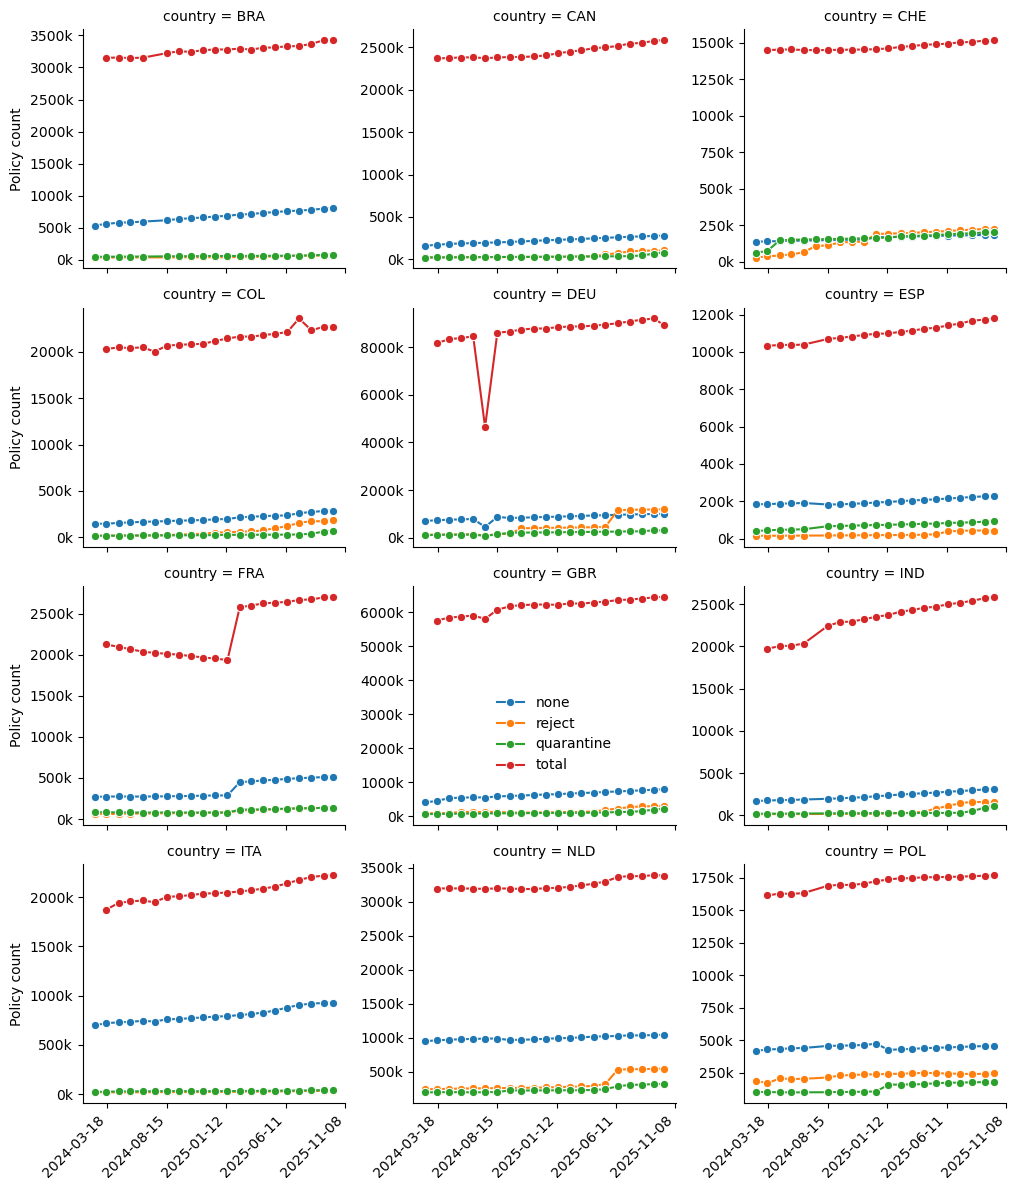

In [93]:
def plot_longitudinal_subset(longitudinal_pdf, subset, filename):
    subset_pdf = longitudinal_pdf[
        (longitudinal_pdf["country"].isin(subset))
        & (longitudinal_pdf["policy"] != "invalid")
    ]
    
    # Faceted line chart
    g = sns.FacetGrid(subset_pdf, col="country", hue="policy", col_wrap=3, sharey=False)
    g.map(sns.lineplot, "timestamp", "count", marker="o", errorbar=None, estimator=None)
    
    for ax in g.axes.flatten():
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k")
        )
        # limit number of x ticks
        ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=5))
        
        # rotate x tick labels
        for label in ax.get_xticklabels():
            label.set_rotation(45)
            label.set_horizontalalignment('right')
    
    g.add_legend(title="")
    g.legend.set_bbox_to_anchor((.54, .38))       # (x, y) relative to figure
    g.legend.set_loc("center")             # anchor from legend’s top center
    #g.legend.set_ncol(3)                         # arrange legend items horizontally
    
    g.set_axis_labels("", "Policy count")
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

# this has the top adopters, top reject, top none
countries_analysis = ["NLD", "DEU", "ITA", "POL", "BRA", "GBR", "CHE", "CAN", "IND", "ESP", "FRA", "COL"]  # -AUS (not present in all snapshots; gap) 
plot_longitudinal_subset(merged_pdf, countries_analysis, "figures/longitudinal_analysis.pdf")

In [216]:
longitudinal_gov_pdf = pd.read_csv("longitudinal_gov_analysis.csv")
# Ensure timestamps are proper datetime
longitudinal_gov_pdf.loc[:, "timestamp"] = pd.to_datetime(subset["timestamp"])
longitudinal_gov_pdf = longitudinal_gov_pdf.sort_values("timestamp")

In [223]:
total_snapshots = longitudinal_gov_pdf["timestamp"].nunique()

# 1) Countries most present across snapshots (regardless of policy)
presence = (
    longitudinal_gov_pdf.groupby("country")["timestamp"]
      .nunique()
      .reset_index(name="snapshots_present")
      .assign(coverage=lambda x: x["snapshots_present"] / total_snapshots)
      .sort_values(["snapshots_present", "coverage"], ascending=False)
)

topN = presence.head(10)
print(topN)

# not enough presence... forget about it

    country  snapshots_present  coverage
52      IND                  7  0.636364
62      KAZ                  7  0.636364
115     RWA                  7  0.636364
47      GUY                  6  0.545455
58      ITA                  6  0.545455
63      KEN                  6  0.545455
106     PHL                  6  0.545455
12      BLR                  5  0.454545
41      GEO                  5  0.454545
61      JPN                  5  0.454545


In [219]:
show_top_variations(longitudinal_gov_pdf, topN=10)

         mean_std_share  max_range_share  avg_mom_TV  max_mom_TV  n_snapshots
country                                                                      
PRY            0.577350              1.0    0.666667         1.0          3.0
GHA            0.577350              1.0    0.666667         1.0          3.0
TTO            0.577350              1.0    0.666667         1.0          3.0
NIC            0.577350              1.0    0.666667         1.0          3.0
TUN            0.525783              1.0    0.500000         1.0          4.0
SLE            0.525783              1.0    0.500000         1.0          4.0
BHR            0.525783              1.0    0.500000         1.0          4.0
HTI            0.525783              1.0    0.500000         1.0          4.0
PNG            0.525783              1.0    0.750000         1.0          4.0
KOR            0.525783              1.0    0.500000         1.0          4.0


In [221]:
all_time_policies(longitudinal_gov_pdf)

top adopters all time


,country,count
40,GBR,72543
129,THA,49626
52,IND,47977
140,UKR,25359
83,MEX,21801
136,TUR,19376
51,IDN,16173
4,ARG,14538
138,TZA,13655
34,ECU,11672


top none all time


,country,count
39,GBR,27775
134,UKR,20313
80,MEX,15900
123,THA,13630
132,TZA,13549
4,ARG,9707
50,IDN,9307
36,ETH,8312
33,ECU,6634
99,PER,5970


top reject all time


,country,count
46,IND,36728
35,GBR,22944
5,AUS,7141
42,HKG,5520
77,MNG,5337
102,SGP,5092
84,NOR,4272
93,POL,3731
100,SAU,3531
86,NZL,3521


top invalid policies all time


### Reporting

In [40]:
# BE CAREFUL EXECUTING THIS CELL! IT WILL TAKE VERY LONG TIME...
longitudinal_reporting_pdf = pd.DataFrame([], columns=["country", "external_reporting", "count", "timestamp"])
longitudinal_reporting_gov_pdf = pd.DataFrame([], columns=["country", "external_reporting", "count", "timestamp"])

for d, df in ct_logs_df_dict.items():
    print(d)
    rua_df = get_dmarc_df(
        df.dropDuplicates(["query_name"]).withColumn(
            "is_gov", is_gov_domain(psf.col("query_name"))
        )
    ).dropDuplicates(["query_name"]).select("query_name", "is_gov", psf.explode_outer("rua_domains").alias("rua_ruf_domain"))
    ruf_df = get_dmarc_df(
        df.dropDuplicates(["query_name"]).withColumn(
            "is_gov", is_gov_domain(psf.col("query_name"))
        )
    ).dropDuplicates(["query_name"]).select("query_name", "is_gov", psf.explode_outer("ruf_domains").alias("rua_ruf_domain"))
    rua_ruf_df = rua_df.unionByName(ruf_df).distinct().withColumn(
        "src_tld", extract_cctld(psf.col("query_name"))
    ).withColumn(
        "dst_tld", extract_cctld(psf.col("rua_ruf_domain"))
    ).withColumn(
        "external_reporting", psf.col("src_tld") == psf.col("dst_tld")
    ).withColumn(
        "country", get_country_from_query(psf.col("query_name"))
    )
    aggr_period_pdf = rua_ruf_df.groupBy(["country", "external_reporting"]).count().withColumn("timestamp", psf.lit(d)).toPandas()
    longitudinal_reporting_pdf = pd.concat([longitudinal_reporting_pdf, aggr_period_pdf], axis=0, ignore_index=True)

    gov_df = rua_ruf_df.filter(psf.col("is_gov") == True)  # for analysis of governments..
    gov_aggr_period_pdf = gov_df.groupBy(["country", "external_reporting"]).count().withColumn("timestamp", psf.lit(d)).toPandas()
    longitudinal_reporting_gov_pdf = pd.concat([longitudinal_reporting_gov_pdf, gov_aggr_period_pdf], axis=0, ignore_index=True)


longitudinal_reporting_pdf.to_csv("longitudinal_reporting_analysis.csv", index=False)
longitudinal_reporting_gov_pdf.to_csv("longitudinal_reporting_gov_analysis.csv", index=False)

2024-02-15 00:00:00
2024-03-15 00:00:00
2024-04-15 00:00:00
2024-05-15 00:00:00
2024-06-15 00:00:00
2024-07-15 00:00:00
2024-08-15 00:00:00
2024-09-15 00:00:00
2024-10-15 00:00:00
2024-11-15 00:00:00
2024-12-15 00:00:00
2025-01-15 00:00:00
2025-02-15 00:00:00
2025-03-15 00:00:00
2025-04-15 00:00:00
2025-05-15 00:00:00
2025-06-15 00:00:00
2025-07-15 00:00:00
2025-08-15 00:00:00
2025-09-15 00:00:00
2025-10-09 00:00:00


In [48]:
countries_analysis = ["NLD", "DEU", "ITA", "POL", "BRA", "GBR", "CHE", "CAN", "IND", "ESP", "FRA", "COL"]
longitudinal_reporting_pdf = pd.read_csv("longitudinal_reporting_analysis.csv")
longitudinal_reporting_gov_pdf = pd.read_csv("longitudinal_reporting_gov_analysis.csv")

longitudinal_reporting_pdf['percent'] = longitudinal_reporting_pdf["count"] / longitudinal_reporting_pdf.groupby(["country", "timestamp"])["count"].transform("sum") * 100
longitudinal_reporting_gov_pdf['percent'] = longitudinal_reporting_gov_pdf["count"] / longitudinal_reporting_gov_pdf.groupby(["country", "timestamp"])["count"].transform("sum") * 100

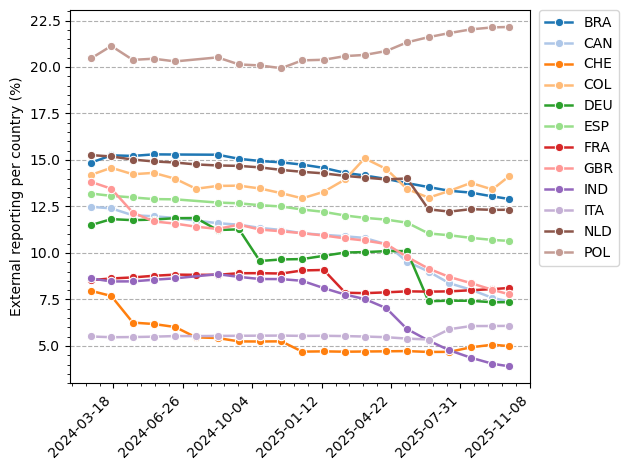

In [77]:
def plot_longitudinal_reporting_subset(longitudinal_reporting_pdf, subset, filename):
    subset_pdf = longitudinal_reporting_pdf[
        (longitudinal_reporting_pdf["country"].isin(subset)) &
        (longitudinal_reporting_pdf["external_reporting"] == True)
    ].copy()

    # Optional: ensure timestamp is sortable (uncomment if timestamps are dates/periods)
    # subset_pdf["timestamp"] = pd.to_datetime(subset_pdf["timestamp"])

    # Aggregate to one value per (country, timestamp) to avoid overplotting
    agg = (
        subset_pdf
        .groupby(["country", "timestamp"], as_index=False)["percent"]
        .mean()
        .sort_values(["timestamp", "country"])
    )

    distinct_colors = [
        "#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2",
        "#D55E00", "#CC79A7", "#999999", "#000000", "#A65628",
        "#4DAF4A", "#984EA3"
    ]
    # Single axes, multiple lines (one per country)
    plt.figure() #figsize=(10.5, 6))
    ax = sns.lineplot(
        data=agg,
        x="timestamp",
        y="percent",
        hue="country",
        marker="o",
        errorbar=None,
        estimator=None,
        lw=1.8,
        palette="tab20",  #distinct_colors #sns.color_palette("Paired", 12),
    )
    ax.minorticks_on()
    ax.grid(True, which="major", axis="y", linestyle="--", linewidth=0.8)
    # Limit number of x ticks and rotate labels
    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=8))
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_horizontalalignment('right')

    ax.set_xlabel("")
    ax.set_ylabel("External reporting per country (%)")
    #ax.set_title("External reporting over time")

    # Put legend outside the plot area
    leg = ax.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)
    # If many countries, you can use multiple columns:
    # leg._legend_box.align = "left"
    # leg.set_ncol(2)

    plt.tight_layout()
    plt.savefig(filename, bbox_inches="tight")
    plt.show()


countries_analysis = ["NLD", "DEU", "ITA", "POL", "BRA", "GBR", "CHE", "CAN", "IND", "ESP", "FRA", "COL"]
plot_longitudinal_reporting_subset(longitudinal_reporting_pdf.copy(), countries_analysis, "figures/longitudinal_reporting_analysis.pdf")

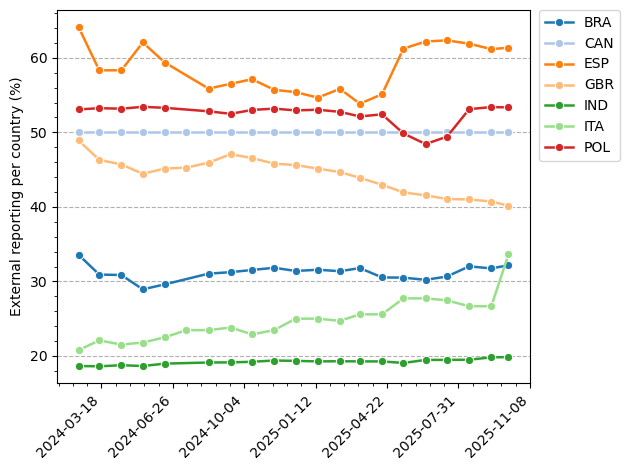

In [78]:
plot_longitudinal_reporting_subset(longitudinal_reporting_gov_pdf.copy(), countries_analysis, "figures/longitudinal_reporting_gov_analysis.pdf")

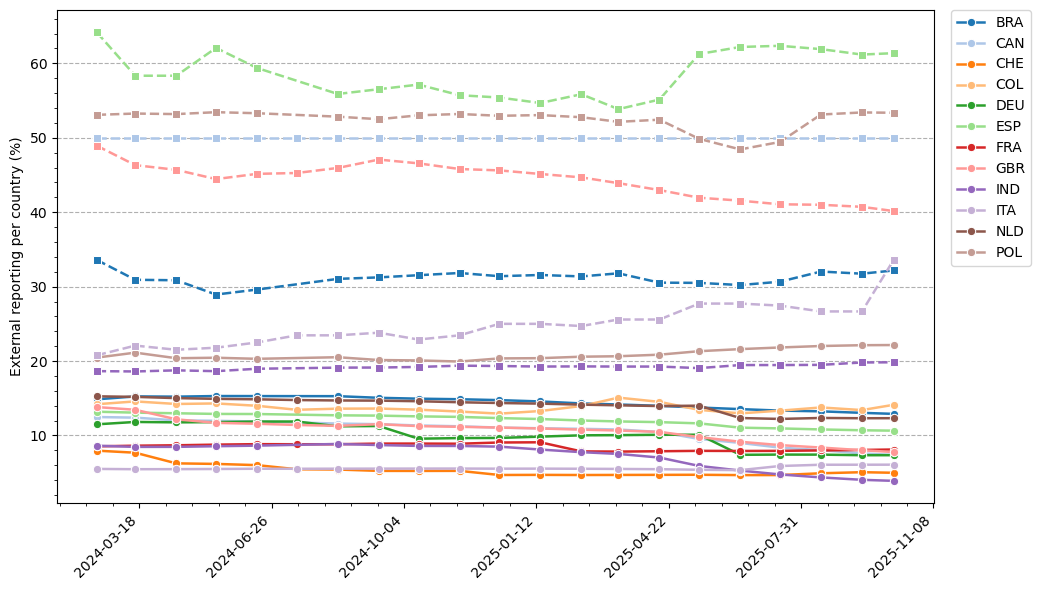

In [88]:
def plot_2_longitudinal_reporting_subset(longitudinal_reporting_pdf, longitudinal2_reporting_pdf, subset, filename):
    # Filter datasets
    subset_pdf = longitudinal_reporting_pdf[
        (longitudinal_reporting_pdf["country"].isin(subset)) &
        (longitudinal_reporting_pdf["external_reporting"] == True)
    ].copy()

    subset2_pdf = longitudinal2_reporting_pdf[
        (longitudinal2_reporting_pdf["country"].isin(subset)) &
        (longitudinal2_reporting_pdf["external_reporting"] == True)
    ].copy()

    # Aggregate to avoid overplotting
    agg = (
        subset_pdf
        .groupby(["country", "timestamp"], as_index=False)["percent"]
        .mean()
        .sort_values(["timestamp", "country"])
    )
    agg2 = (
        subset2_pdf
        .groupby(["country", "timestamp"], as_index=False)["percent"]
        .mean()
        .sort_values(["timestamp", "country"])
    )

    # Consistent color palette
    all_countries = sorted(set(agg["country"]) | set(agg2["country"]))
    palette = sns.color_palette("tab20", len(all_countries))
    color_map = dict(zip(all_countries, palette))

    # --- Plot ---
    plt.figure(figsize=(10.5, 6))
    ax = sns.lineplot(
        data=agg,
        x="timestamp",
        y="percent",
        hue="country",
        palette=color_map,
        marker="o",
        lw=1.8,
        linestyle="-",
        legend=True,
    )

    # Second dataset: same colors, dashed lines
    sns.lineplot(
        data=agg2,
        x="timestamp",
        y="percent",
        hue="country",
        palette=color_map,
        marker="s",
        lw=1.8,
        linestyle="--",
        legend=True,
        ax=ax,
    )

    # --- Formatting ---
    ax.minorticks_on()
    ax.grid(True, which="major", axis="y", linestyle="--", linewidth=0.8)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=8))
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_horizontalalignment('right')

    ax.set_xlabel("")
    ax.set_ylabel("External reporting per country (%)")

    # Single legend with countries only
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:len(subset)], all_countries,
              #title="Country",
              bbox_to_anchor=(1.02, 1),
              loc="upper left", borderaxespad=0.)

    plt.tight_layout()
    plt.savefig(filename, bbox_inches="tight")
    plt.show()



plot_2_longitudinal_reporting_subset(longitudinal_reporting_pdf.copy(), longitudinal_reporting_gov_pdf.copy(), countries_analysis, "figures/longitudinal_reporting_comb_analysis.pdf")

## Data overview

In [59]:
gov_meas_date = datetime(2025, 9, 30)
gov_meas_df = spark.read.json(
    f"s3a://catrin/measurements/tool=zdns/vp=nl/format=raw/category=fdns/record=txt/subdomain=_dmarc/port=53/year={gov_meas_date.year}/month={gov_meas_date.month:02d}/day={gov_meas_date.day:02d}/output.json"
)
gov_aggr_pdf = gov_meas_df.select("results.TXT.status").groupBy("status").count().toPandas()
gov_aggr_pdf.columns = ["status", "gov"]
total_gov = gov_aggr_pdf["gov"].sum()

mx_meas_date = datetime(2025, 10, 10)
mx_meas_df = spark.read.json(
    f"s3a://catrin/measurements/tool=zdns/vp=nl/format=raw/category=fdns/record=mx/subdomain=fqdn/port=53/year={mx_meas_date.year}/month={mx_meas_date.month:02d}/day={mx_meas_date.day:02d}/output.json"
)
mx_aggr_pdf = mx_meas_df.select("results.MX.status").groupBy("status").count().toPandas()
mx_aggr_pdf.columns = ["status", "MX"]
total_mx = mx_aggr_pdf["MX"].sum()

a_meas_date = datetime(2025, 10, 11)
a_meas_df = spark.read.json(
    f"s3a://catrin/measurements/tool=zdns/vp=nl/format=raw/category=fdns/record=a/subdomain=fqdn/port=53/year={a_meas_date.year}/month={a_meas_date.month:02d}/day={a_meas_date.day:02d}/output.json"
)
a_aggr_pdf = a_meas_df.select("results.A.status").groupBy("status").count().toPandas()
a_aggr_pdf.columns = ["status", "A"]
total_a = a_aggr_pdf["A"].sum()

In [61]:
merged_pdf = (
    gov_aggr_pdf.merge(mx_aggr_pdf, on="status", how="outer")
          .merge(a_aggr_pdf, on="status", how="outer")
          .fillna(0)
          .astype({'gov': int, 'MX': int, 'A': int})
)
merged_pdf.loc[len(merged_pdf)] = ['Total', total_gov, total_mx, total_a]

merged_pdf = merged_pdf.sort_values("gov", ascending=False)

display(merged_pdf)

formatters = {
        'gov': lambda x: f"{int(x):,}",
        'MX': lambda x: f"{int(x):,}",
        'A': lambda x: f"{int(x):,}",
    }
print(
    merged_pdf.to_latex(
        columns=[
            "status", 
            'gov',
            'MX',
            'A',
        ],
        caption="DNS measurements overview",
        label="tab:dns_meas_overview",
        index=False,
        formatters=formatters,
        position="ht",
    )
)
print(f'Date & {gov_meas_date.year}-{gov_meas_date.month:02d}-{gov_meas_date.day:02d} & {mx_meas_date.year}-{mx_meas_date.month:02d}-{mx_meas_date.day:02d} & {a_meas_date.year}-{a_meas_date.month:02d}-{a_meas_date.day:02d} \\\ ')

,status,gov,MX,A
5,Total,10111,1815495,1058601
1,NOERROR,5798,1726854,1013738
3,NXDOMAIN,3989,29287,43763
0,TIMEOUT,231,58052,894
2,SERVFAIL,93,886,206
4,ERROR,0,416,0


\begin{table}[ht]
\caption{DNS measurements overview}
\label{tab:dns_meas_overview}
\begin{tabular}{lrrr}
\toprule
status & gov & MX & A \\
\midrule
Total & 10,111 & 1,815,495 & 1,058,601 \\
NOERROR & 5,798 & 1,726,854 & 1,013,738 \\
NXDOMAIN & 3,989 & 29,287 & 43,763 \\
TIMEOUT & 231 & 58,052 & 894 \\
SERVFAIL & 93 & 886 & 206 \\
ERROR & 0 & 416 & 0 \\
\bottomrule
\end{tabular}
\end{table}

Date & 2025-09-30 & 2025-10-10 & 2025-10-11 \\ 


In [74]:
print("all domains queried for TXT record")  # this considers dmarc duplications... Don't add this number to the paper...
all_domains_cnt = ct_gov_df.filter(
    (psf.col("query_type") == "TXT")  # useless filter because ct logs data were extracted already using it.
    # & (psf.col("response_name").isNotNull())  # exists; doesn't matter if it has TXT record or no; UPDATE names on CT logs will exist, otherwise they would not appear on the ct log
).select("query_name").distinct().count()  # query_name does not contain _dmarc.
print(all_domains_cnt)
# 745039  --> tranco

all domains queried for TXT record
19292317


In [75]:
if False:
    print("all cctld domains")
    ct_gov_df.filter(
        (psf.col("query_type") == "TXT")
        # & (psf.col("response_name").isNotNull())
    ).select("query_name"
    ).withColumn(
        "removed_dmarc", psf.regexp_replace("query_name", r"^_dmarc.", "")
    ).dropDuplicates(["removed_dmarc"]
    ).withColumn(
        "tld", extract_cctld(psf.col("query_name"))
    ).groupBy("tld").count(
    ).groupBy("tld").agg(psf.sum(psf.col("count")).alias("total_domains")
    ).agg(psf.sum(psf.col("total_domains"))).show()
    #298631

In [102]:
print("countries counts on all domains")

output = f"s3a://luvizottocesarg-tmp/oi-warehouse/source={source}/countries_counts/year={last_snapshot.year}/month={last_snapshot.month:02d}/day={last_snapshot.day:02d}"

if False:
    ct_gov_df.select("query_name"
    ).distinct(
    ).withColumn(
        "country", get_country_from_query("query_name")
    ).groupBy("country").count(
    ).groupBy("country").agg(psf.sum(psf.col("count")).alias("total_domains")
    ).sort("total_domains", ascending=False
    ).select("country", "total_domains"
    ).coalesce(1).write.option("header", "true").csv(output)

apices_df.filter(
    psf.col("date") == psf.lit(f"{last_snapshot.year}-{last_snapshot.month:02d}-{last_snapshot.day:02d}")
).withColumn(
    "country", get_country_from_query("tld")
).groupBy("country").agg(psf.sum(psf.col("apex_count")).alias("total_domains")
).sort("total_domains", ascending=False
).select("country", "total_domains"
).coalesce(1).write.option("header", "true").csv(output)

countries counts on all domains


In [77]:
print("# ccTLD domains using DMARC -- excluding domains with duplicated records")

get_dmarc_df(ct_gov_df).select("query_name").distinct(
).count()

# 173252 tranco

# ccTLD domains using DMARC -- excluding domains with duplicated records


19196800

In [89]:
#"Policy applies to the domain queried and to subdomains,
# unless subdomain policy is explicitly described using the "sp" tag." - rfc7489#section-6.3
def has_policy(df):
    return df.withColumn(
            "has_policy", psf.when((psf.col("p").isNull()) & (psf.col("sp").isNull()), False
        ).otherwise(True)
    )

has_policy(get_dmarc_df(ct_gov_df).dropDuplicates(["query_name"])).groupBy("has_policy").count().show()

+----------+--------+
|has_policy|   count|
+----------+--------+
|      true|19185237|
|     false|   11563|
+----------+--------+



In [79]:
ct_gov_df.withColumn(
    "tld", extract_cctld(psf.col("query_name"))
).groupBy("tld").count(
).sort("count", ascending=False).toPandas().to_csv("ct_logs_tlds.csv", index=False)

In [80]:
ct_logs_tlds_pdf = pd.read_csv("ct_logs_tlds.csv")

ct_logs_tlds_pdf["country"] = ct_logs_tlds_pdf["tld"].apply(lambda x: get_country_from_query_logic(x, psl_obj, country_mapping, country_convert_mapping))

print(
    "All ccTLDs",
    len(ct_logs_tlds_pdf),
    "countries analized",
    len(ct_logs_tlds_pdf[~ct_logs_tlds_pdf["country"].isnull()])
)

All ccTLDs 301 countries analized 290


In [81]:
print("# gov related domains using DMARC")
get_dmarc_df(ct_gov_df).dropDuplicates(["query_name"]).groupBy("is_gov").count().show()
# tranco
#|  true|  7066|
#| false|415728|

# merged egov un ctlogs
#|  true|   35780|
#| false|18770709|

# gov related domains using DMARC
+------+--------+
|is_gov|   count|
+------+--------+
|  true|   36334|
| false|19160466|
+------+--------+



In [90]:
has_policy(
    get_dmarc_df(ct_gov_df).dropDuplicates(["query_name"]).filter(psf.col("is_gov") == True)
).groupBy("has_policy").count().show()

+----------+-----+
|has_policy|count|
+----------+-----+
|      true|36094|
|     false|  240|
+----------+-----+



In [82]:
print("# ccTLDs in gov related domains that use DMARC")

print(
get_dmarc_df(ct_gov_df).select("query_name").distinct(
).filter(
    psf.col("is_gov") == True
).withColumn(
    "tld", extract_cctld(psf.col("query_name"))
).groupBy("tld").count().count()
)

# ccTLDs in gov related domains that use DMARC
165


In [83]:
print("# countries in gov related domains that use DMARC")

print(
get_dmarc_df(ct_gov_df).select("query_name").distinct(
).withColumn(
    "tld", extract_cctld(psf.col("query_name"))
).filter(
    psf.col("is_gov") == True
).withColumn(
    "country", get_country_from_query(psf.col("query_name"))
).groupBy("country").count().count()
)

# 145 --> tranco

# countries in gov related domains that use DMARC
156


In [24]:
try:
    cctld_dmarc_df.unpersist()
except:
    pass

dmarc_df = get_dmarc_df(ct_gov_df)

cctld_dmarc_df = dmarc_df.withColumn(
        "tld", extract_cctld(psf.col("query_name"))
    )
    # we don't need the cctld_df anymore...
    #.join(
    #    cctld_df, on=["tld"], how="inner"
    #)

cctld_dmarc_df.persist()

DataFrame[apex_domain: string, query_name: string, is_gov: boolean, p: string, sp: string, aspf: string, adkim: string, rua_domains: array<string>, ruf_domains: array<string>, tld: string]

In [85]:
def show_rua_ruf_stats(df):
    dmarc_report_address_df = df.withColumn(
        "has_rua", psf.when(psf.size(psf.col("rua_domains")) == 0, False).otherwise(True)
    ).withColumn(
        "has_ruf", psf.when(psf.size(psf.col("ruf_domains")) == 0, False).otherwise(True)
    )
    
    either_rua_ruf_nr = dmarc_report_address_df.filter((psf.col("has_rua") == True) | (psf.col("has_ruf") == True)).select("query_name").distinct().count()
    rua_nr = dmarc_report_address_df.filter(psf.col("has_rua") == True).select("query_name").distinct().count()
    ruf_nr = dmarc_report_address_df.filter(psf.col("has_ruf") == True).select("query_name").distinct().count()
    
    dmarc_domains_cnt = df.select("query_name").distinct().count()
    
    print(
        "either rua or ruf:", either_rua_ruf_nr, "out of", dmarc_domains_cnt,
        round(either_rua_ruf_nr / dmarc_domains_cnt * 100, 1), "%",
    
        "\nrua:", rua_nr, "out of", dmarc_domains_cnt,
        round(rua_nr / dmarc_domains_cnt * 100, 1), "%",
    
        "\nruf:", ruf_nr, "out of", dmarc_domains_cnt,
        round(ruf_nr / dmarc_domains_cnt * 100, 1), "%"
    )

    if False:
        dmarc_report_address_df.groupBy("has_rua", "has_ruf").count().withColumn(
            "percen
            t", psf.lit(100) * psf.col('count') / psf.sum('count').over(Window.partitionBy())
        ).show()


show_rua_ruf_stats(cctld_dmarc_df)
#either rua or ruf: 115509 out of 173486 66.6 % 
#rua: 113502 out of 173486 65.4 % 
#ruf: 59441 out of 173486 34.3 %

either rua or ruf: 5759894 out of 19196800 30.0 % 
rua: 5652355 out of 19196800 29.4 % 
ruf: 1905359 out of 19196800 9.9 %


spoofed paper (p.13): rua: 41.99%, ruf: 20.57%

Comparison with related work:  
[Spoofed] - czds, passive DNS SIE EU, CT logs, Tranco 5M; Table 2: 
NO MX, DMARC with rua/ruf = 1,270,352  
NO MX, DMARC without rua/ruf = 909,347  
MX, DMARC with rua/ruf = 5,435,578  
MX, DMARC without rua/ruf = 8,354,295  

[Ashiq]  
TLD,  Domains with MX Records,DMARC,DMARC %, Report,Report %, Report from Ext.,Report from Ext. %  
.com, 75.6M,                  5.0M, 6.6%,    2.4M, 49.4%,     1.7M, 68.8%  
.net, 6.5M,                   453K, 6.9%,    245K, 54.1%,     172K, 70.2%  
.org, 5.8M,                   390K, 6.7%,    213K, 54.5%,     152K, 71.4%  
.se,  848K,                   81K,  9.6%,    30K,  37.4%,     24K,  80.1%  

In [86]:
show_rua_ruf_stats(
    cctld_dmarc_df.withColumn(
        "is_gov", is_gov_domain(psf.col("query_name"))
    ).filter(psf.col("is_gov") == True)
)
#either rua or ruf: 5793 out of 7194 80.5 % 
#rua: 5736 out of 7194 79.7 % 
#ruf: 3917 out of 7194 54.4 %

either rua or ruf: 19876 out of 36201 54.9 % 
rua: 19632 out of 36201 54.2 % 
ruf: 12020 out of 36201 33.2 %


In [25]:
cctld_dmarc_df = cctld_dmarc_df.withColumn(
    "country", get_country_from_query(psf.col("query_name"))
).dropDuplicates(subset=["query_name"])

In [170]:
output = f"s3a://luvizottocesarg-tmp/oi-warehouse/source={source}/cctld_dmarc/year={last_snapshot.year}/month={last_snapshot.month:02d}/day={last_snapshot.day:02d}"
cctld_dmarc_df.write.parquet(output)

## RQ1 - How DMARC is used in different countries

See other jupyter notebook in https://github.com/gustavoluvizotto/dmarc-aggr-report-dependency/blob/main/notebooks/process-results.ipynb

## RQ2 - How DMARC reporting is used in different countries

### Extracting graph

In [18]:
mx_date = datetime(2025, 10, 10)
p = f"s3a://catrin/measurements/tool=zdns/vp=nl/format=raw/category=fdns/record=mx/subdomain=fqdn/port=53/year={mx_date.year}/month={mx_date.month:02d}/day={mx_date.day:02d}/output.json"
mx_df = spark.read.json(p
).select(psf.col("name").alias("rua_ruf_domain"), psf.explode_outer("results.MX.data.answers.answer").alias("mx_name"))

ip2loc_date = datetime(2025, 10, 13)
p = f"s3a://luvizottocesarg-tmp/oi-warehouse/source=ct_logs/a_answer/year={ip2loc_date.year}/month={ip2loc_date.month:02d}/day={ip2loc_date.day:02d}/ip2location_rua_ruf_mx_a_answer/"
ip2loc_df = spark.read.option("header", "true").format("csv").load(p, schema=psf.StructType([
    pst.StructField("name", pst.StringType()),
    pst.StructField("ip", pst.StringType()),
    pst.StructField("ip_decimal", pst.FloatType()),
    pst.StructField("cc", pst.StringType()),
    pst.StructField("c_name", pst.StringType()),
    pst.StructField("isp", pst.StringType()),
    pst.StructField("usage_type", pst.StringType()),
])).withColumnRenamed("name", "mx_name")

In [19]:
# don't need to run this again...
if False:
    ip2loc_df.groupBy("c_name").count().select("c_name").toPandas().to_csv("country_full_names_ip2loc.csv", index=False)

In [20]:
def country_full_to_alpha3(x):
    if x == "Korea (the Republic of)":
        x = "Korea, Republic of"
        return pycountry.countries.search_fuzzy(x)[0].alpha_3
    if x == "Niger":
        return pycountry.countries.get(name=x).alpha_3
    if x == "-":
        return None
    if x == "Curacao":
        x = "Curaçao"
        return pycountry.countries.get(name=x).alpha_3
    if x == "Sint Maarten (Dutch part)":
        return pycountry.countries.get(name=x).alpha_3
    if x == "Virgin Islands (U.S.)":
        x = "Virgin Islands, U.S."
        return pycountry.countries.get(name=x).alpha_3
    return pycountry.countries.search_fuzzy(x.split(",")[0].split("(")[0].split("[")[0])[0].alpha_3

country_full_pdf = pd.read_csv("country_full_names_ip2loc.csv")
country_full_pdf["country"] = country_full_pdf["c_name"].apply(lambda x: country_full_to_alpha3(x))
country_full_mapping = dict(zip(country_full_pdf['c_name'], country_full_pdf['country']))
assert len(country_full_mapping) == len(country_full_pdf)

In [21]:
broadcast_country_full_mapping = spark.sparkContext.broadcast(country_full_mapping)


@psf.pandas_udf(pst.StringType())
def convert_country_full_to_alpha3(c_name: pd.Series) -> pd.Series:
    _country_full_mapping = broadcast_country_full_mapping.value
    def _convert_country_full_to_alpha3(x):
        return _country_full_mapping[x]
    return c_name.apply(_convert_country_full_to_alpha3)


def get_country_rua_ruf_domains():
    # loading mx 
    mx_date = datetime(2025, 10, 10)
    p = f"s3a://catrin/measurements/tool=zdns/vp=nl/format=raw/category=fdns/record=mx/subdomain=fqdn/port=53/year={mx_date.year}/month={mx_date.month:02d}/day={mx_date.day:02d}/output.json"
    mx_df = spark.read.json(p
    ).select(psf.col("name").alias("rua_ruf_domain"), psf.explode_outer("results.MX.data.answers.answer").alias("mx_name"))

    # loading ip2loc data
    ip2loc_date = datetime(2025, 10, 13)
    p = f"s3a://luvizottocesarg-tmp/oi-warehouse/source=ct_logs/a_answer/year={ip2loc_date.year}/month={ip2loc_date.month:02d}/day={ip2loc_date.day:02d}/ip2location_rua_ruf_mx_a_answer/"
    ip2loc_df = spark.read.option("header", "true").format("csv").load(p, schema=psf.StructType([
        pst.StructField("name", pst.StringType()),
        pst.StructField("ip", pst.StringType()),
        pst.StructField("ip_decimal", pst.FloatType()),
        pst.StructField("cc", pst.StringType()),
        pst.StructField("c_name", pst.StringType()),
        pst.StructField("isp", pst.StringType()),
        pst.StructField("usage_type", pst.StringType()),
    ])).withColumnRenamed("name", "mx_name")

    return mx_df.join(
        ip2loc_df,
        on=["mx_name"],
        how="inner"
    ).groupBy("rua_ruf_domain").agg(
        psf.collect_set("c_name").alias("c_names")
    ).select("rua_ruf_domain", psf.explode_outer(psf.col("c_names")).alias("c_name")
    ).withColumn(
        "rua_ruf_country", convert_country_full_to_alpha3(psf.col("c_name"))
    ).filter(
        psf.col("rua_ruf_country").isNotNull()
    ).select("rua_ruf_domain", "rua_ruf_country")

In [72]:
# using GraphFrames
def create_graphframes_from_pyspark_df(df, scan_date):

    rua_ruf_df = get_country_rua_ruf_domains()

    # apex_domain = sld.tld (using regex domain_pattern)
    apex_vertices_df = df.select("apex_domain", "country", "is_gov").dropDuplicates(subset=["apex_domain"])
    apex_vertices_df = apex_vertices_df.withColumn("domain_type", psf.lit("organizational_domain"))

    rua_df = rua_ruf_df.select(psf.col("rua_ruf_domain").alias("rua_domain"), psf.col("rua_ruf_country").alias("country"))
    rua_vertices_df = df.select(psf.explode_outer("rua_domains").alias("rua_domain")
    ).join(
        rua_df,
        on=["rua_domain"],
        how="inner"
    ).withColumn(
        "rua_apex_domain", extract_apex_domain(psf.col("rua_domain"))
    ).select(psf.col("rua_apex_domain").alias("apex_domain"), "country").distinct()
    rua_vertices_df = rua_vertices_df.withColumn("is_gov", is_gov_domain(psf.col("apex_domain")))
    rua_vertices_df = rua_vertices_df.withColumn("domain_type", psf.lit("rua_domain"))
    #rua_vertices_df = rua_vertices_df.withColumn("country", psf.lit("RUA_CC"))
    #rua_vertices_df = rua_vertices_df.withColumnRenamed("rua_country", "country")

    ruf_df = rua_ruf_df.select(psf.col("rua_ruf_domain").alias("ruf_domain"), psf.col("rua_ruf_country").alias("country"))
    ruf_vertices_df = df.select(psf.explode_outer("ruf_domains").alias("ruf_domain")
    ).join(
        ruf_df,
        on=["ruf_domain"],
        how="inner"
    ).withColumn(
        "ruf_apex_domain", extract_apex_domain(psf.col("ruf_domain"))
    ).select(psf.col("ruf_apex_domain").alias("apex_domain"), "country").distinct()
    ruf_vertices_df = ruf_vertices_df.withColumn("is_gov", is_gov_domain(psf.col("apex_domain")))
    ruf_vertices_df = ruf_vertices_df.withColumn("domain_type", psf.lit("ruf_domain"))
    #ruf_vertices_df = ruf_vertices_df.withColumn("country", psf.lit("RUF_CC"))  # FIXME with new meas.
    #rua_vertices_df = rua_vertices_df.withColumnRenamed("ruf_country", "country")

    
    # id (=apex_domain of query_name, rua_domain, ruf_domain), is_gov (=is the domain a governmental domain?
    # type_country (list of strings, elements separated by ; and each element is a pair of type and country='type|country;type|country')
    # type_country format is neo4j specific.
    vertices = apex_vertices_df.unionByName(rua_vertices_df).unionByName(ruf_vertices_df).select(
        psf.col("apex_domain").alias("id"), "is_gov", "domain_type", "country"
    ).groupBy("id").agg(
        psf.collect_set("is_gov").alias("is_gov_list"),
        psf.concat_ws(";", psf.collect_set(psf.concat_ws("|", "domain_type", "country"))).alias("type_country"),
    ).withColumn(
        "is_gov", psf.lower(
            psf.when(psf.size(psf.col("is_gov_list")) > 1, psf.lit(True)
              ).otherwise(psf.element_at("is_gov_list", 1)
            ).cast("string")
        )
    ).select(
        psf.col("id"),
        psf.col("type_country"),
        psf.col("is_gov")
    )
    #).dropDuplicates(subset=["id"])  # last distinct over registered, rua and ruf domains
    #).dropDuplicates(subset=["id", "country"])  # last distinct over registered, rua and ruf domains

    # src(=apex_domain), dst(=rua/ruf_apex_domain), edge_type(rua/ruf)
    # Create edges for RUA relationships
    rua_edges = df.select(psf.col("apex_domain").alias("src"),
                          psf.explode_outer("rua_domains").alias("rua_domain"),
                          psf.lit("rua").alias("edge_type")
        ).join(
            rua_df,
            on=["rua_domain"],
            how="inner"
        ).withColumn(
            "rua_apex_domain", extract_apex_domain(psf.col("rua_domain"))
        ).filter(psf.col("rua_apex_domain").isNotNull()
        ).select(
            psf.col("src"),
            psf.col("rua_apex_domain").alias("dst"),
            psf.col("edge_type")
        ).distinct()

    
    # Create edges for RUF relationships
    ruf_edges = df.select(psf.col("apex_domain").alias("src"),
                          psf.explode_outer("ruf_domains").alias("ruf_domain"),
                          psf.lit("ruf").alias("edge_type")
        ).join(
            ruf_df,
            on=["ruf_domain"],
            how="inner"
        ).withColumn(
            "ruf_apex_domain", extract_apex_domain(psf.col("ruf_domain"))
        ).filter(psf.col("ruf_apex_domain").isNotNull()
        ).select(
            psf.col("src"),
            psf.col("ruf_apex_domain").alias("dst"),
            psf.col("edge_type").alias("edge_type")
        ).distinct()
    
    # Union all edges
    edges = rua_edges.union(ruf_edges)
    
    return GraphFrame(vertices, edges)

G = create_graphframes_from_pyspark_df(cctld_dmarc_df, last_snapshot)

In [69]:
# Graph statistics
# for GraphFrame
print(f"Number of nodes: {G.vertices.count()}")
print(f"Number of edges: {G.edges.count()}")
gov_domains_cnt = G.vertices.filter(psf.col("is_gov") == True).count()
print(f"Number of gov nodes: {gov_domains_cnt}")

num_ruas = G.edges.filter("edge_type = 'rua'").count()
print("The number of RUA edges is", num_ruas)

num_rufs = G.edges.filter("edge_type = 'ruf'").count()
print("The number of RUF edges is", num_rufs)

# without filter cctlds on tranco 20250711:
#Number of nodes: 435893
#Number of edges: 346886
#The number of RUA edges is 315303
#The number of RUF edges is 158240
# filtered ccTLD
#Number of nodes: 181859
#Number of edges: 188323
#The number of RUA edges is 125719
#The number of RUF edges is 62604
# CT logs (with explode in country)
#Number of nodes: 19293685
#Number of edges: 7763681
#The number of RUA edges is 5808227
#The number of RUF edges is 1955454
# CT logs (no dups)
#Number of nodes: 19274719
#Number of edges: 7376627
#Number of gov nodes: 36855
#The number of RUA edges is 5590138
#The number of RUF edges is 1786489

Number of nodes: 19274719
Number of edges: 7376627
Number of gov nodes: 36855
The number of RUA edges is 5590138
The number of RUF edges is 1786489


Export graph to import in neo4j

In [74]:
# exporting vertices and edges to s3 to load with neo4j
edges_output = f"s3a://luvizottocesarg-tmp/oi-warehouse/source={source}/graph_edges/year={last_snapshot.year}/month={last_snapshot.month:02d}/day={last_snapshot.day:02d}"
vertices_output = f"s3a://luvizottocesarg-tmp/oi-warehouse/source={source}/graph_vertices/year={last_snapshot.year}/month={last_snapshot.month:02d}/day={last_snapshot.day:02d}"

G.edges.write.parquet(edges_output)
G.vertices.write.parquet(vertices_output)

In [75]:
spark.read.parquet(vertices_output).count()

19274719

In [22]:
# run out of memory
if False:
    result = G.connectedComponents()
    
    (result.sort("component")
    .groupby("component")
    .agg(F.collect_list("id").alias("apex_domain"))
    .show(truncate=False))

Export ip2loc data

In [27]:
output = f"s3a://luvizottocesarg-tmp/oi-warehouse/source=new_meas/rua_ruf_country/year={last_snapshot.year}/month={last_snapshot.month:02d}/day={last_snapshot.day:02d}"

get_country_rua_ruf_domains().coalesce(1).write.option("header", "true").csv(output)

In [28]:
spark.read.csv(output).count()

2134005

## RQZ

OLD: Get DMARC measurements from domains that exist and that have an MX server

In [37]:
if False:
    # unpersist what is going to be persisted in this cell in case we run the cell 2x
    try:
        dmarc_w_mx_df.unpersist()
    except:
        pass
    
    # limit mx_names_df to speed up execution
    # a domain that may have dmarc meas and mx server may appear without having them because of this cut;
    limit = 0  # all; no limit
    #limit = 10000
    
    # domains may have 2 TXT answers for _dmarc queries. E.g.:
    # dig -t txt +short _dmarc.vaktija.ba
    #"v=DMARC1; p=reject; sp=reject; adkim=s; aspf=s;"
    #"v=DMARC1; p=none; rua=mailto:postmaster@vaktija.ba"
    apex_df = tranco_df.filter(
        (psf.col("query_type") == "MX")
        | (psf.col("query_type") == "TXT")
        | (psf.col("query_type") == "A")
    ).withColumn(
        "apex_domain", extract_apex_domain(psf.col("query_name"))
    ).select("query_name", "query_type", "apex_domain", "ip4_address", "mx_address", "year", "month", "day", "country", "txt_text")
    
    # apply limit of apex domain to speed up analysis. Comment this code
    if limit == 0:
        df = apex_df
    else:
        lim_distinct_domains = apex_df.select("apex_domain").dropDuplicates().limit(limit)
        lim_apex_df = apex_df.join(lim_distinct_domains, on="apex_domain", how="inner")
        df = lim_apex_df
    
    window = Window.partitionBy("apex_domain")
    
    flags_df = df.withColumn(
        "has_dmarc", psf.max(psf.when(psf.col("query_name").startswith("_dmarc."), 1).otherwise(0)).over(window)
    ).withColumn(
        "has_mx", psf.max(psf.when((psf.col("query_type") == "MX") & psf.col("mx_address").isNotNull(), 1).otherwise(0)).over(window)
    ).withColumn(
        "has_ip", psf.max(psf.when(psf.col("ip4_address").isNotNull(), 1).otherwise(0)).over(window)
    )
    
    # Filter for domains that have both DMARC and MX records
    dmarc_w_mx_df = flags_df.filter(
        (psf.col("has_dmarc") == 1)
        #& (psf.col("has_mx") == 1)
    ).drop("has_dmarc", "has_mx", "has_ip")
    
    #if limit == 0:
    dmarc_w_mx_df.persist()
    
    dmarc_w_mx_df.show(truncate=False)

    # limit is non deterministic
    dmarc_w_mx_df.count() 
    
    # I did some filtering (domains that has_dmarc and has_mx), that's why is not "lim" anymore
    dmarc_w_mx_df.select("apex_domain").distinct().count()

    lim_distinct_domains.count()

    dmarc_mx_path = f"s3a://luvizottocesarg-tmp/oi-warehouse/testing/source=tranco/year={start_date.year}/month={start_date.month:02d}/day={start_date.day:02d}"
    dmarc_w_mx_df.write.parquet(dmarc_mx_path)

Required to speed up analysis...

In [10]:
dmarc_w_mx_df = spark.read.parquet(dmarc_mx_path)

In [11]:
# for limit to be deterministic, it's better to use sample(n, seed=1234).
dmarc_w_mx_df.count()
# limit + tranco of 2024,3,14:
# 43040
# limit + tranco of 2025,7,11:
# 62946

62946

In [38]:
dmarc_w_mx_df.groupBy("query_type").count().show()
# limit + tranco of 2024,3,14:
#+----------+-----+
#|query_type|count|
#+----------+-----+
#|        MX| 8910|
#|       TXT|19809|
#|         A|14321|
#+----------+-----+
# limit + tranco of 2025,7,11:
#+----------+-----+
#|query_type|count|
#+----------+-----+
#|        MX|11007|
#|       TXT|26477|
#|         A|19230|
#+----------+-----+

+----------+-----+
|query_type|count|
+----------+-----+
|        MX|11007|
|       TXT|26477|
|         A|19230|
+----------+-----+



#### How many of these are organizations, private users, and others?

In [41]:
#apx_ruas_rufs_df = dmarc_df
#apx_ruas_rufs_df = extract_rua_ruf_domains(dmarc_w_mx_df).groupBy("apex_domain"  # one domain may have multiple TXT records
#).agg(
#    psf.collect_set("rua_domains").alias("rua_domains_list"),   # list(list)
#    psf.collect_set("ruf_domains").alias("ruf_domains_list")  # list(list))
#)

In [11]:
rua_output = f"s3a://luvizottocesarg-tmp/oi-warehouse/testing/aggregation/what=rua_addresses/source={source}/year={start_date.year}/month={start_date.month:02d}/day={start_date.day:02d}"
ruf_output = f"s3a://luvizottocesarg-tmp/oi-warehouse/testing/aggregation/what=ruf_addresses/source={source}/year={start_date.year}/month={start_date.month:02d}/day={start_date.day:02d}"

In [87]:
# CAREFUL WHEN USING THE FULL DATASET. IT MAY NEED TO SAVE TO OBJSTORE AND THEN LOAD IT AGAIN...
aggr_rua_df = dmarc_df.select(psf.explode("rua_domains").alias("rua_domain")
).groupBy("rua_domain").count().withColumn(
    "rua_apex_domain", extract_apex_domain(psf.col("rua_domain"))
).groupBy("rua_apex_domain").agg(psf.sum(psf.col("count"))
).withColumn(
    "percent", psf.lit(100) * psf.col('sum(count)') / psf.sum('sum(count)').over(Window.partitionBy())
).sort("percent", ascending=False)
aggr_rua_df.write.parquet(rua_output)

aggr_ruf_df = dmarc_df.select(psf.explode("ruf_domains").alias("ruf_domain")
).groupBy("ruf_domain").count().withColumn(
    "ruf_apex_domain", extract_apex_domain(psf.col("ruf_domain"))
).groupBy("ruf_apex_domain").agg(psf.sum(psf.col("count"))
).withColumn(
    "percent", psf.lit(100) * psf.col('sum(count)') / psf.sum('sum(count)').over(Window.partitionBy())
).sort("percent", ascending=False)
aggr_ruf_df.write.parquet(ruf_output)

#output = f"s3a://luvizottocesarg-tmp/oi-warehouse/aggregation/what=rua_ruf_addresses/source={source}/year={start_date.year}/month={start_date.month:02d}/day={start_date.day:02d}"
#aggr_rua_ruf_df = aggr_rua_df.select(psf.col("rua_apex_domain").alias("rua_ruf_apex_domain"), psf.col("sum(count)")).union(aggr_ruf_df.select(psf.col("ruf_apex_domain").alias("rua_ruf_apex_domain"), psf.col("sum(count)"))
#).groupBy("rua_ruf_apex_domain").agg(psf.sum(psf.col("sum(count)"))
#).select("rua_ruf_apex_domain", psf.col("sum(sum(count))").alias("count")
#).withColumn(
#    "percent", psf.lit(100) * psf.col('count') / psf.sum('count').over(Window.partitionBy())
#).sort("percent", ascending=False)
#aggr_rua_ruf_df.write.parquet(output)

In [51]:
aggr_rua_pdf = spark.read.parquet(rua_output).toPandas()
aggr_ruf_pdf = spark.read.parquet(ruf_output).toPandas()

Py4JJavaError: An error occurred while calling o917.collectToPython.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 0 in stage 194.0 failed 4 times, most recent failure: Lost task 0.3 in stage 194.0 (TID 3162) (192.168.47.119 executor 5): TaskResultLost (result lost from block manager)
Driver stacktrace:
	at org.apache.spark.scheduler.DAGScheduler.failJobAndIndependentStages(DAGScheduler.scala:2856)
	at org.apache.spark.scheduler.DAGScheduler.$anonfun$abortStage$2(DAGScheduler.scala:2792)
	at org.apache.spark.scheduler.DAGScheduler.$anonfun$abortStage$2$adapted(DAGScheduler.scala:2791)
	at scala.collection.mutable.ResizableArray.foreach(ResizableArray.scala:62)
	at scala.collection.mutable.ResizableArray.foreach$(ResizableArray.scala:55)
	at scala.collection.mutable.ArrayBuffer.foreach(ArrayBuffer.scala:49)
	at org.apache.spark.scheduler.DAGScheduler.abortStage(DAGScheduler.scala:2791)
	at org.apache.spark.scheduler.DAGScheduler.$anonfun$handleTaskSetFailed$1

The final plot is in a local jupyter notebook.

How many times multiple mailto: is present in rua/ruf tags?

In [27]:
dmarc_df.withColumn(
    "nr_ruas", psf.size("rua_domains")
).groupBy("nr_ruas").count().show()

dmarc_df.withColumn(
    "nr_rufs", psf.size("ruf_domains")
).groupBy("nr_rufs").count().show()

+-------+------+
|nr_ruas| count|
+-------+------+
|      1|250111|
|      3|  2789|
|      4|   280|
|      2| 28889|
|      0|144379|
|      5|    26|
|      6|     7|
|      7|     2|
+-------+------+

+-------+------+
|nr_rufs| count|
+-------+------+
|      1|138607|
|      6|     1|
|      3|   558|
|      2|  9698|
|      0|277582|
|      4|    33|
|      5|     4|
+-------+------+



How many corner cases among all domains?

In [15]:
#bgazrt.hu BGAZRT.HU
#conferencenext.com mailinblue.com!10m
#crediautos.cl crediautos
#fruugo.com.tr
#mydwoje.pl dplads.com>
#pravslovo.ru pravslovo.ruadkim=r
#cambridgeone.org cambridge.o
#cfc.org.br tuxon.com.br._report._dmarc
#drogaraia.com.br DMARC.EVEREST.EMAIL
#gatefy.com mailto
#xiantao.gov.cn qiye.163.com.
#xtreme.bet xtreme.bet\
#anglesey.gov.uk ruf.aga
#astroved.com pct=100
case = 'agricolors.fr'

# THESE VARIABLES DOES NOT EXIST ANYMORE
dmarc_w_mx_df.filter(
    (psf.col("query_type") == "TXT")
    & (psf.col("query_name").startswith("_dmarc."))
    & (psf.col("query_name").contains(case))
).select("txt_text").show(truncate=False)

apx_ruas_rufs_df.filter(
    psf.col("apex_domain").contains(case)
).show(truncate=False)

+---------------------------------------------------------------------------------------------------------------------------------+
|txt_text                                                                                                                         |
+---------------------------------------------------------------------------------------------------------------------------------+
|"v=DMARC1; p=none; sp=none; rua=mailto:dmarc@mailinblue.com!10m; ruf=mailto:dmarc@mailinblue.com!10m; rf=afrf; pct=100; ri=86400"|
|NULL                                                                                                                             |
+---------------------------------------------------------------------------------------------------------------------------------+

+--------------+----------------------+----------------------+
|apex_domain   |rua_addresses_list    |ruf_addresses_list    |
+--------------+----------------------+----------------------+
|agricolors.fr.|[[

In [13]:
# corner cases - with limit and tranco 2024:
# 1 - email domain has a typo
# a - missing TLD in one of the mailto
# apex_domain="crediautos.cl" -> "v=DMARC1; p=reject; fo=1; rua=mailto:dmarc_rua@emaildefense.proofpoint.com; ruf=mailto:dmarc_ruf@emaildefense.proofpoint.com;"
# b - characters (quotes) added to the rua/ruf domain name
# apex_domain="cambridgeone.org" -> "v=DMARC1; p=quarantine; rua=mailto:644b4767adf94d2a9f33fbe1b9072971@dmarc-reports.cloudflare.net,mailto:047acbdc29a7625@rep.dmarcanalyzer.com,mailto:dmarc-admin@cambridge.org; ruf=mailto:047acbdc29a7625@for.dmarcanalyzer.com,mailto:dmarc-admin@cambridge.o""rg; fo=1;"
# apex_domain="xtreme.bet" -> "\"v=DMARC1; p=reject; sp=reject; ruf=mailto:authfail@xtreme.bet; rua=mailto:aggrep@xtreme.bet\""
# apex_domain="anglesey.gov.uk" -> ruf=mailto:isle-of-anglesey-council@ruf.aga""ri-eu.com,mailto:dmarc-rua@dmarc.service.gov.uk
# c - misinterpretation of the standard
# apex_domain="cfc.org.br" -> "v=DMARC1;p=none;pct=100;rua=mailto:postmaster@mensageiro.tuxon.com.br,mailto:mensageiro@tuxon.com.br._report._dmarc"
# d - typo on mailto:
# apex_domain="gatefy.com" -> ruf=mailto:ed75d258-6313-11ea-bc55-0242ac130003@antifraud.gatefy.com,mailto:support@gatefy.com,mailto"":6a13379d44@ruf.easydmarc.com;"

# 2 - domain name is malformed according to RFC 5321 because of the syntax of domain name is not valid according to RFC 1035 sec. 2.3.1
# apex_domain="siter.io" -> ma""ilinblue.com!10m
# a - the quotation problem entail a different domain mailto:dmarc-ruf@pushwoosh.io,mailto:dmarc@pushwoosh.co  -- LIVE WITH IT!
# apex_domain="pushwoosh.com" -> "v=DMARC1; p=quarantine; sp=quarantine; pct=100; rua=mailto:c9312ab8@mxtoolbox.dmarc-report.com,mailto:dmarc-rua@pushwoosh.io,mailto:dmarc@pushwoosh.com; ruf=mailto:c9312ab8@forensics.dmarc-report.com,mailto:dmarc-ruf@pushwoosh.io,mailto:dmarc@pushwoosh.co""m; fo=1" 
# 3 - malformed txt record; additional quotes
# apex_domain="fruugo.com.tr" -> """v=DMARC1;""p=none;""sp=none;""pct=100;""ri=2419200;""rua=mailto:dmarc.reports@fruugo.com;""ruf=mailto:dmarc.reports@fruugo.com\"\""
# 4 - rua ending with > instead of only ;
# apex_domain="mydwoje.pl" -> "v=DMARC1; p=none; rua=mailto:dmarc@2zcfjaj2.uriports.com,mailto:dmarc@dplads.com>; ruf=mailto:dmarc@2zcfjaj2.uriports.com,dmarc@dplads.com>; fo=1:d:s"
# 5 - no ; between tags
# apex_domain="pravslovo.ru" -> "v=DMARC1; p=quarantine; rua=mailto:webmaster@pravslovo.ru; ruf=mailto:webmaster@pravslovo.ru adkim=r; aspf=s; pct=100; ri=86400; sp=none"
# apex_domain="astroved.com" -> "v=DMARC1;p=reject;rua=mailto:kameshvaran@astroved.com,pct=100;adkim=s;aspf=s"

queries = ["_dmarc.crediautos.cl.", 
           "_dmarc.cambridgeone.org.", 
           "_dmarc.xtreme.bet.", 
           "_dmarc.anglesey.gov.uk.", 
           "_dmarc.cfc.org.br.", 
           "_dmarc.gatefy.com.", 
           "_dmarc.siter.io.", 
           "_dmarc.pushwoosh.com.", 
           "_dmarc.fruugo.com.tr.", 
           "_dmarc.mydwoje.pl.", 
           "_dmarc.pravslovo.ru.", 
           "_dmarc.astroved.com."]

tranco_df.filter(
    (psf.col("query_type") == "TXT" )
    & (psf.col("query_name").isin(queries))
).select("query_name", "txt_text").show(truncate=False)

# ok and invalid labels coming from checkdmarc python library
domain_txt_dict = {
    'crediautos.cl': 'v=DMARC1; p=reject; fo=1; rua=mailto:dmarc_rua@emaildefense.proofpoint.com; ruf=mailto:dmarc_ruf@emaildefense.proofpoint.com;',  # ok
    'cambridgeone.org': 'v=DMARC1; p=quarantine; rua=mailto:644b4767adf94d2a9f33fbe1b9072971@dmarc-reports.cloudflare.net,mailto:047acbdc29a7625@rep.dmarcanalyzer.com,mailto:dmarc-admin@cambridge.org; ruf=mailto:047acbdc29a7625@for.dmarcanalyzer.com,mailto:dmarc-admin@cambridge.o""rg; fo=1;',  # invalid
    'xtreme.bet': '"v=DMARC1; p=reject; sp=reject; ruf=mailto:authfail@xtreme.bet; rua=mailto:aggrep@xtreme.bet"',  # ok
    'cfc.org.br': 'v=DMARC1; p=quarantine; fo=1; pct=5; rua=mailto:postmaster@cfc.org.br',  # pct value is less than 100. This leads to inconsistent and unpredictable policy enforcement
    'pushwoosh.com': 'v=DMARC1; p=quarantine; sp=quarantine; pct=100; rua=mailto:c9312ab8@mxtoolbox.dmarc-report.com,mailto:dmarc-rua@pushwoosh.io,mailto:dmarc@pushwoosh.com; ruf=mailto:c9312ab8@forensics.dmarc-report.com,mailto:dmarc-ruf@pushwoosh.io,mailto:dmarc@pushwoosh.co""m; fo=1',  # invalid
    'fruugo.com.tr': '""v=DMARC1;""p=none;""sp=none;""pct=100;""ri=2419200;""rua=mailto:dmarc.reports@fruugo.com;""ruf=mailto:dmarc.reports@fruugo.com""',  # invalid
    'siter.io': 'v=DMARC1; p=reject; p=quarantine; sp=none; rua=mailto:b6912d25d63842beb6825c439fe06625@dmarc-reports.cloudflare.net,mailto:ipm2sg0@ar.glockapps.com,mailto:re+af96ffc2ba6c@inbound.dmarcdigests.com,mailto:re+jv1mk3mupdi@dmarc.postmarkapp.com,mailto:dmarc@ma""ilinblue.com!10m; ruf=mailto:ipm2sg0@fr.glockapps.com,mailto:dmarc@mailinblue.com!10m; aspf=r; fo=1; rf=afrf; ri=86400;',  # invalid
    'gatefy.com': 'v=DMARC1; p=quarantine; pct=100; fo=1; ri=3600; rua=mailto:ed75d258-6313-11ea-bc55-0242ac130003@antifraud.gatefy.com,mailto:6a13379d44@rua.easydmarc.com; ruf=mailto:ed75d258-6313-11ea-bc55-0242ac130003@antifraud.gatefy.com,mailto:support@gatefy.com,mailto"":6a13379d44@ruf.easydmarc.com;',  # invalid
    'pravslovo.ru': 'v=DMARC1; p=quarantine; rua=mailto:webmaster@pravslovo.ru; ruf=mailto:webmaster@pravslovo.ru adkim=r; aspf=s; pct=100; ri=86400; sp=none',   # invalid - manually added
    'mydwoje.pl': 'v=DMARC1; p=none; rua=mailto:dmarc@2zcfjaj2.uriports.com,mailto:dmarc@dplads.com>; ruf=mailto:dmarc@2zcfjaj2.uriports.com,dmarc@dplads.com>; fo=1:d:s',  # invalid - manually added
}

+------------------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|query_name              |txt_text                                                                                                                                                                                                                                                                                                                                                                                  |
+------------------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [30]:
cases = ["genelec.ba", "somn.io", "jgean.com.br", "vesely-drak.cz", "rentrabb.it", "actens.io", "univsul.edu.iq", "mariowii.nl", "kamody.cz", 
         "payakumbuhkota.go.id", "ipboxcloud.com.br", "pinkfort.co", "green-edem.com.ua", "menfp.gouv.ht", "top4running.ro", "novissajoias.com.br", 
         "mosaico-cem.it", "le7sorelle.it", "vkino.com.ua", "netcon.com.br", "endlessmode.jp", "thechristmasshop.com.au", "hokutetsu.co.jp", "energieker.it", 
         "martens-tweewielers.nl", "augusta-staff.jp", "customs.go.jp", "empresaqui.com.br", "visor.ph", "fnspfdr.sk", "colosseumticket.cz", "k2a.ru", 
         "comfortflex.com.br", "svetbot.cz", "foxtrail.ch", "green-edem.com.ua", "roast.by", "internet.gr", "sellis-it.nl", "revi.io"]

extract_dmarc_tags(tranco_df).select("query_name", "rua_domains", "ruf_domains", "txt_text").withColumn(
    "apex_domain", extract_apex_domain(psf.col("query_name"))
).filter(
    psf.col("apex_domain").isin(cases)
).select("apex_domain", psf.explode_outer("rua_domains").alias("rua_domain"), psf.explode_outer("ruf_domains").alias("ruf_domain"), "txt_text"
).withColumn(
    "rua_apex_domain", extract_apex_domain(psf.col("rua_domain"))
).withColumn(
    "ruf_apex_domain", extract_apex_domain(psf.col("ruf_domain"))
).show(100, truncate=False)


+-----------------------+------------------------------------------+---------------------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------------+---------------+
|apex_domain            |rua_domain                                |ruf_domain                       |txt_text                                                                                                                                                                       |rua_apex_domain |ruf_apex_domain|
+-----------------------+------------------------------------------+---------------------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------------+---------------+
|fnspfdr.sk             |hostcreators.sk hostcreators.sk        

### Graph analysis - testing

#### How interconnected are third-party DMARC processors and domain owners?

In [89]:
print("\nTop 5 reporting destinations")
G.inDegrees.sort("inDegree", ascending=False).show(5, truncate=False)

self_loop_cnt = G.edges.filter(G.edges.src == G.edges.dst).count()
print(f"\nSelf-reporting domains - not external report: {self_loop_cnt}")

external_cnt = G.edges.filter(G.edges.src != G.edges.dst).count()
print(f"\nReports to an external domain: {external_cnt}")
#pagerank = G.pageRank(resetProbability=0.01, maxIter=20)
#pagerank.vertices.select("id", "pagerank").show(5, truncate=False)


Top 5 reporting destinations
+----------------------------+--------+
|id                          |inDegree|
+----------------------------+--------+
|proofpoint.com              |27464   |
|dmarc-reports.cloudflare.net|21680   |
|vali.email                  |15331   |
|dmarcanalyzer.com           |14837   |
|dmarcian.com                |14741   |
+----------------------------+--------+
only showing top 5 rows


Self-reporting domains - not external report: 187160

Reports to an external domain: 277354


In [15]:
# Search for pairs of vertices with edges in both directions between them.
motifs = G.find("(a)-[e]->(b); (b)-[e2]->(a)")
print(motifs.count())

302390


In [18]:
# Find chains of 4 vertices.
chain4 = G.find("(a)-[ab]->(b); (b)-[bc]->(c); (c)-[cd]->(d)")

# Query on sequence, with state (cnt)
#  (a) Define method for updating state given the next element of the motif.
def cum_edges(cnt, edge):
    edge_type = psf.col(edge)["edge_type"]
    return psf.when(edge_type == "rua", cnt + 1).otherwise(cnt)

#  (b) Use sequence operation to apply method to sequence of elements in motif.
#   In this case, the elements are the 3 edges.
edges = ["ab", "bc", "cd"]
num_edge_types = reduce(cum_edges, edges, psf.lit(0))
    
chainWith2Friends2 = chain4.withColumn("num_edges", num_edge_types).where(num_edge_types >= 2)
chainWith2Friends2.show()
print(chainWith2Friends2.count())

+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+---------+
|                   a|                  ab|                   b|                  bc|                   c|                  cd|                   d|num_edges|
+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+---------+
|       {1-rk.com.ua}|{1-rk.com.ua, 1-r...|       {1-rk.com.ua}|{1-rk.com.ua, 1-r...|       {1-rk.com.ua}|{1-rk.com.ua, 1-r...|       {1-rk.com.ua}|        3|
|{1000grad-epaper.de}|{1000grad-epaper....|{1000grad-epaper.de}|{1000grad-epaper....|{1000grad-epaper.de}|{1000grad-epaper....|{1000grad-epaper.de}|        3|
| {100directions.com}|{100directions.co...| {100directions.com}|{100directions.co...| {100directions.com}|{100directions.co...| {100directions.com}|        3|
|          {100sp.ru}|{100sp.ru, 100sp....|   

In [19]:
# "detecting communities in networks.
# Each node in the network is initially assigned to its own community.
# At every superstep, nodes send their community affiliation to all neighbors and update their state to the most frequent community affiliation of incoming messages."
# https://docs.databricks.com/aws/en/notebooks/source/graphframes-user-guide-py.html
G.labelPropagation(maxIter=5).show()

+--------------------+-------------+
|                  id|        label|
+--------------------+-------------+
|  1000grad-epaper.de|            0|
|      SiouxChief.com| 231928235824|
|        abstract.com|           26|
| ac-aix-marseille.fr|           29|
|    adventsource.org|           54|
|            agent.ru|           65|
|          ampfit.com|          112|
|           amsnet.pl|          113|
|     artofthepot.com|          155|
|     astrocenter.com|          167|
|     azamgarh.nic.in|          191|
|     basicincome.org|          222|
|        betterce.com| 841813592038|
|  blogdomagno.com.br|          270|
|         blynk.cloud|  51539607825|
|         bnbcash.app|          278|
|     bookeasy.com.au| 678604833317|
|          bosfera.ru|          293|
|boutiqueauxmainsd...|   8589936674|
|      brainmarket.cz|1382979469562|
+--------------------+-------------+
only showing top 20 rows



In [11]:
G.triangleCount().sort("count", ascending=False).show(truncate=False)

+-----+----------------------------+
|count|id                          |
+-----+----------------------------+
|1056 |vali.email                  |
|706  |proofpoint.com              |
|262  |playtika.com                |
|238  |dmarcian.com                |
|227  |dhs.gov                     |
|201  |dmarc-reports.cloudflare.net|
|177  |postmarkapp.com             |
|135  |dmarcadvisor.com            |
|126  |dmarcdigests.com            |
|120  |agari.com                   |
|118  |dmarcanalyzer.com           |
|116  |powerdmarc.com              |
|99   |ondmarc.com                 |
|91   |dmarc-report.com            |
|69   |easydmarc.us                |
|67   |gm.com                      |
|65   |dmarc.gov.sa                |
|65   |wolterskluwer.com           |
|60   |dyson.com                   |
|60   |redsift.cloud               |
+-----+----------------------------+
only showing top 20 rows



## RQ2 - What is the geographical distribution of DMARC report receivers, domain owners and their email servers, and what are the potential implications of cross jurisdictional data transit?

#### What is the proportion of domains that outsource DMARC processing to another country?

## RQ3 - How DMARC report receivers evolved over the course of 1 year?

#### Has usage of ruf tags changed over time?

#### Has dependency on third-party processors increased or decreased over time?

## Epilogue

In [ ]:
clean_spark()

## Old/unused code

##### Using NetworkX -- deprecated

In [18]:
# using NetworkX
def create_graph_from_pyspark_df(df, good_error_domains):
    """
    Convert PySpark DataFrame to NetworkX graph
    """
    # Convert to Pandas for easier graph creation
    pdf = df.toPandas()

    # Create directed graph
    domain_graph = nx.DiGraph()

    # Add nodes (all unique domains)
    all_domains = set()
    for _, row in pdf.iterrows():
        ruas = row['rua_domains_list'] if row['rua_domains_list'] else [[]]
        rufs = row['ruf_domains_list'] if row['ruf_domains_list'] else [[]]
        flat_ruas_rufs = set(list(itertools.chain(*(ruas+rufs))))

        apex = row['apex_domain'].rstrip('.')
        all_domains.add(apex)

        # below is for statistics
        good_rua_ruf_tags_cnt = 0
        bad_rua_ruf_tags_cnt = 0
        for domain in flat_ruas_rufs:
            if not domain or domain == "":
                continue
            def match_domain(pattern, domain):
                m = re.search(pattern, domain, re.IGNORECASE)
                if m:
                    apex_domain = f"{m.group(1)}.{m.group(2)}"
                    all_domains.add(apex_domain)
                return m

            if match_domain(domain_pattern, domain):
                good_rua_ruf_tags_cnt += 1
            else:
                bad_rua_ruf_tags_cnt += 1

        # statistics
        good_error_domains[apex] = [good_rua_ruf_tags_cnt, bad_rua_ruf_tags_cnt]

    domain_graph.add_nodes_from(all_domains)

    # Add edges for RUA/RUF relationships
    def add_edges(domain_graph, pdf, rua_ruf_col, edge_type):
        for _, row in pdf.iterrows():
            apex = row['apex_domain'].rstrip('.')
            rua_ruf_list = row[rua_ruf_col] if row[rua_ruf_col] else [[]]
            rua_ruf = set(list(itertools.chain(*rua_ruf_list)))

            for domain in rua_ruf:
                if not domain or domain == "":
                    continue
                m = re.search(domain_pattern, domain, re.IGNORECASE)
                if m:
                    rua_ruf_apex = f"{m.group(1)}.{m.group(2)}"
                    domain_graph.add_edge(apex, rua_ruf_apex, edge_type=edge_type, label=edge_type.upper())


    add_edges(domain_graph, pdf, "rua_domains_list", "rua")

    add_edges(domain_graph, pdf, "ruf_domains_list", "ruf")

    return domain_graph

# Create the graph
good_error_domains = defaultdict(list)
G = create_graph_from_pyspark_df(apx_ruas_rufs_df, good_error_domains)

In [ ]:
# for NetworkX:
if False:
    print(f"Number of nodes: {G.number_of_nodes()}")
    print(f"Number of edges: {G.number_of_edges()}")
    print(f"Is directed: {G.is_directed()}")
    
    print("nr of apex domains in the graph:")
    print(len(good_error_domains.keys()))
    
    print("nr of domains with one or more errors:")
    one_or_more_tags_wrong_cnt = 0
    for domain, cnt_list in good_error_domains.items():
        good_cnt = cnt_list[0]
        bad_cnt = cnt_list[1]
        if bad_cnt > 0:
            one_or_more_tags_wrong_cnt += 1
    print(one_or_more_tags_wrong_cnt)
    
    # how many have all rua/ruf with errors
    print("how many apex domains have all tags wrong (ie won't be sending reports anyway)?")
    all_tags_wrong_cnt = 0
    for domain, cnt_list in good_error_domains.items():
        good_cnt = cnt_list[0]
        bad_cnt = cnt_list[1]
        if good_cnt == 0 and bad_cnt > 0:
            all_tags_wrong_cnt += 1
    print(all_tags_wrong_cnt)
    # tranco 2024,3,14 with limit=10000
    #Number of nodes: 4042
    #Number of edges: 2438
    #Is directed: True
    #nr of apex domains in the graph:
    #3597
    #nr of domains with one or more errors:
    #67
    #how many apex domains have all tags wrong (ie won't be sending reports anyway)?
    #50
    #

# NetworkX
if False:
    # Find nodes with highest in-degree (most popular reporting destinations)
    in_degrees = dict(G.in_degree())
    top_reporting_destinations = sorted(in_degrees.items(), key=lambda x: x[1], reverse=True)[:5]
    print("\nTop 5 reporting destinations - nr of domains resporting to these:")
    for domain, count in top_reporting_destinations:
        print(f"  {domain}: {count}")
    
    # Find self-reporting domains (domains that report to themselves)
    self_reporting = [node for node in G.nodes() if G.has_edge(node, node)]
    print(f"\nSelf-reporting domains - not external report: {len(self_reporting)}")
    
    external_reporting = [node for node in G.nodes() if not G.has_edge(node, node)]
    print(f"\nReports to an external domain: {len(external_reporting)}")
    # tranco 2024,3,14; limit=10000
    #Top 5 reporting destinations - nr of domains resporting to these:
    #  dmarc-reports.cloudflare.net: 135
    #  proofpoint.com: 101
    #  vali.email: 100
    #  dmarcian.com: 76
    #  dmarcanalyzer.com: 68

    #Self-reporting domains - not external report: 1099

    #Reports to an external domain: 2943
    #

In [55]:
# Visualization function
def visualize_graph(G, figsize=(15, 10)):
    """
    Visualize the graph with different colors for different edge types
    """
    plt.figure(figsize=figsize)
    
    # Create layout
    pos = nx.spring_layout(G, k=3, iterations=50)
    
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', 
                          node_size=300, alpha=0.7)
    
    # Draw RUA edges in blue
    rua_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('edge_type') == 'rua']
    nx.draw_networkx_edges(G, pos, edgelist=rua_edges, 
                          edge_color='blue', alpha=0.6, width=1.5, 
                          arrowsize=20, label='RUA (Aggregate)')
    
    # Draw RUF edges in red
    ruf_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('edge_type') == 'ruf']
    nx.draw_networkx_edges(G, pos, edgelist=ruf_edges, 
                          edge_color='red', alpha=0.6, width=1.5, 
                          arrowsize=20, label='RUF (Failure)')
    
    # Draw labels for important nodes only (to avoid clutter)
    important_nodes = {node: node for node, degree in in_degrees.items() if degree > 1}
    nx.draw_networkx_labels(G, pos, important_nodes, font_size=8)
    
    plt.title("DMARC Reporting Relationships Graph")
    plt.legend()
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
# Create and show the visualization
visualize_graph(G)

In [109]:
# Export NetworkX graph data for external tools
def export_graph_data(G, filename_prefix="dmarc_graph"):
    """
    Export graph data in various formats
    """
    # Export as GraphML (can be opened in Gephi, Cytoscape, etc.)
    nx.write_graphml(G, f"{filename_prefix}.graphml")
    
    # Export edge list as CSV
    edges_df = pd.DataFrame(G.edges(data=True))
    edges_df.to_csv(f"{filename_prefix}_edges.csv", index=False)
    
    # Export node list as CSV
    nodes_df = pd.DataFrame({"node": list(G.nodes())})
    nodes_df.to_csv(f"{filename_prefix}_nodes.csv", index=False)
    
    print(f"Graph exported as {filename_prefix}.graphml")
    print(f"Edges exported as {filename_prefix}_edges.csv")
    print(f"Nodes exported as {filename_prefix}_nodes.csv")

export_graph_data(G)

Graph exported as dmarc_graph.graphml
Edges exported as dmarc_graph_edges.csv
Nodes exported as dmarc_graph_nodes.csv


## Anycast sites -- unused

IP addresses from all the rua/ruf mail servers (MX) and cross-check with AnycastCensus dataset.  
Anycast dataset: https://github.com/ut-dacs/anycast-census/blob/main/2025/10/10/IPv4.csv  

In [2]:
anycast_dataset = "anycast-IPv4-prefixes-20251010.csv"
anycast_pdf = pd.read_csv(anycast_dataset)
display(anycast_pdf)
#anycast_df = spark.DataFrame(anycast_pdf)  # confirm
# TODO: join anycast_df.backing__prefix with rua_ruf_a_records_measurements

,prefix,number_of_sites,backing_prefix
0,1.0.0.0/24,64,1.0.0.0/24
1,1.1.1.0/24,64,1.1.1.0/24
2,1.10.10.0/24,2,1.10.10.0/24
3,1.12.0.0/24,5,1.12.0.0/20
4,1.12.12.0/24,3,1.12.0.0/20
...,...,...,...
13447,99.83.254.0/24,47,99.83.240.0/20
13448,99.83.255.0/24,47,99.83.240.0/20
13449,99.99.97.0/24,2,99.96.0.0/13
13450,99.99.98.0/24,2,99.96.0.0/13
